# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Rebha-ds/flyrank-first-ml-assignment/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

Ranking, because I'm ranking(sorting) pages based on which 

## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

In [2]:
import pandas as pd
df= pd.read_csv("C:/Users/Nelson/anaconda_projects/flyrank internship/flyrank-first-ml-assignment/data/raw/content_refresh_anonymized.csv")
df_ctr=pd.DataFrame()
df_ctr = df[[
    # Identifiers
    'content_id', 'client_id', 
    # Foundational Content & Keyword Context
    'content_type', 'main_intent', 'search_volume', 'competition', 'competition_level', 
    'word_count', 'word_count_tier', 'content_age_days', 'freshness_tier',
    # Top of Funnel Metrics (CTR & Impressions)
    'days_with_impressions', 'impressions_90d', 'clicks_90d', 
    'impressions_last_30d', 'clicks_last_30d', 
    'impressions_prev_30d', 'clicks_prev_30d', 
    'ctr', 'avg_position', 'impression_tier', 'position_tier',
    # Bottom of Loop / Advanced Channels & Trends
    'ai_sessions_90d', 'ai_traffic_pct', 'trend_direction', 'trend_pct'
]].copy()
df_engagement=pd.DataFrame()
df_engagement=df[[
    # Identifiers
    'content_id', 'client_id', 
    # Foundational Content Context & Generation Metadata
    'content_type', 'main_intent', 'provider_used', 'model_used', 
    'word_count', 'char_count', 'word_count_tier', 'char_count_tier', 
    'content_age_days', 'age_tier', 'age_tier_order', 
    'days_since_last_update', 'freshness_tier',
    # Middle of Funnel Metrics (Engagement & UX)
    'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 
    'scroll_events_90d', 'days_with_sessions', 
    'sessions_last_30d', 'sessions_prev_30d', 
    'engagement_rate', 'scroll_rate',
    # Bottom of Loop / Advanced Channels & Trends
    'ai_sessions_90d', 'ai_traffic_pct', 'trend_direction', 'trend_pct'
]].copy()

In [3]:
# data cleaning for ctr dataframe
print(df_ctr[df_ctr['competition_level'].isnull() & df_ctr['competition'].notnull()])
# 1. Store your groupby min/max table into a variable
comp_ranges = df_ctr.groupby('competition_level')['competition'].agg(['min', 'max'])

# 2. Create a function to check which range a value belongs to
def find_competition_level(comp_value):
    # Loop through each level and its min/max limits
    for level, limits in comp_ranges.iterrows():
        # Check if the value falls within this level's range
        if limits['min'] <= comp_value <= limits['max']:
            return level
            
    # Return whatever it originally was (or None) if it doesn't fit any range
    return None 

# 3. Create a mask (filter) to find exactly the rows you want to update
mask = df_ctr['competition_level'].isnull() & df_ctr['competition'].notnull()

# 4. Apply the function ONLY to the masked rows, and update 'competition_level'
df_ctr.loc[mask, 'competition_level'] = df_ctr.loc[mask, 'competition'].apply(find_competition_level)


                 content_id          client_id     content_type main_intent  \
139    content_e46f4ebd9fe9  client_7f2253d7e2  keyword article         NaN   
592    content_0a631257482b  client_f369cb89fc  keyword article         NaN   
750    content_f4de869ba53d  client_7f2253d7e2  keyword article         NaN   
1458   content_2fcd75499332  client_7f2253d7e2  keyword article         NaN   
1507   content_b23087b81e66  client_7f2253d7e2  keyword article         NaN   
...                     ...                ...              ...         ...   
29413  content_aeff85e1f8ca  client_7f2253d7e2  keyword article         NaN   
29566  content_09f654d4117a  client_f369cb89fc  keyword article         NaN   
29763  content_31998e499b2a  client_7f2253d7e2  keyword article         NaN   
29826  content_3264452ca44a  client_7f2253d7e2  keyword article         NaN   
29854  content_69ce2b6411b3  client_6208ef0f77  keyword article         NaN   

       search_volume  competition competition_level

In [4]:
print(df_ctr.info())
print(df_ctr.columns)

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   content_id             30000 non-null  str    
 1   client_id              30000 non-null  str    
 2   content_type           30000 non-null  str    
 3   main_intent            27626 non-null  str    
 4   search_volume          27532 non-null  float64
 5   competition            27532 non-null  float64
 6   competition_level      27532 non-null  str    
 7   word_count             22301 non-null  float64
 8   word_count_tier        22301 non-null  str    
 9   content_age_days       30000 non-null  int64  
 10  freshness_tier         30000 non-null  str    
 11  days_with_impressions  30000 non-null  int64  
 12  impressions_90d        30000 non-null  int64  
 13  clicks_90d             30000 non-null  int64  
 14  impressions_last_30d   30000 non-null  int64  
 15  clicks_last_3

In [5]:
print(df_ctr.describe())

       search_volume   competition    word_count  content_age_days  \
count   27532.000000  27532.000000  22301.000000       30000.00000   
mean      158.882391      0.146954   3107.760325         256.16780   
std      1518.270825      0.285241   1452.382598         132.70793   
min         0.000000      0.000000      8.000000          90.00000   
25%         0.000000      0.000000   2413.000000         132.00000   
50%        10.000000      0.000000   2877.000000         236.00000   
75%        20.000000      0.130000   3666.000000         333.00000   
max     74000.000000      1.000000   9546.000000         564.00000   

       days_with_impressions  impressions_90d    clicks_90d  \
count           30000.000000     30000.000000  30000.000000   
mean               61.454033      5200.366300     16.097333   
std                32.689245     16838.019547     75.076958   
min                 1.000000         1.000000      0.000000   
25%                31.000000        81.000000      0.0

In [6]:
print(df_engagement.describe())
print(df_engagement.columns)

         word_count     char_count  content_age_days  age_tier_order  \
count  22301.000000   22301.000000       30000.00000    30000.000000   
mean    3107.760325   20665.277835         256.16780        4.786533   
std     1452.382598   10115.344042         132.70793        0.790392   
min        8.000000      40.000000          90.00000        3.000000   
25%     2413.000000   15644.000000         132.00000        4.000000   
50%     2877.000000   19116.000000         236.00000        5.000000   
75%     3666.000000   24011.000000         333.00000        5.000000   
max     9546.000000  111158.000000         564.00000        6.000000   

       days_since_last_update  pageviews_90d  sessions_90d     users_90d  \
count            30000.000000   30000.000000  30000.000000  30000.000000   
mean                46.098300      49.942467     37.066633     35.937700   
std                 42.078709     152.101430    107.069131    103.748185   
min                  1.000000       0.000000   

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def plot_features_vs_targets_side_by_side(df1, df2, label1, label2, feature_cols, target_cols, max_categories=10):
    """Automatically generates bivariate side-by-side plots comparing two dataframes 
    for every feature against multiple target columns.
    """
    sns.set_theme(style="whitegrid")

    for feature in feature_cols:
        num_targets = len(target_cols)
        # Create a figure with a row for each target, and 2 columns (for df1 and df2)
        fig, axes = plt.subplots(
            num_targets, 2, figsize=(12, 4 * num_targets), squeeze=False
        )
        fig.suptitle(
            f"Feature: '{feature}' | {label1} vs {label2}", fontsize=14, y=1.05
        )

        for i, target in enumerate(target_cols):
            # Iterate through both dataframes to plot them side-by-side
            for j, (df, label) in enumerate([(df1, label1), (df2, label2)]):
                ax = axes[i, j]
                
                # Safety check if column is missing
                if feature not in df.columns or target not in df.columns:
                    ax.set_title(f"Missing column in {label}")
                    continue

                is_feat_num = pd.api.types.is_numeric_dtype(df[feature])
                is_targ_num = pd.api.types.is_numeric_dtype(df[target])

                # 1. Numerical Feature vs Numerical Target
                if is_feat_num and is_targ_num:
                    sns.scatterplot(
                        data=df, x=feature, y=target, ax=ax, alpha=0.3, edgecolor=None, s=15
                    )
                    ax.set_title(f"[{label}] vs {target}")

                # 2. Numerical Feature vs Categorical Target
                elif is_feat_num and not is_targ_num:
                    sns.boxplot(
                        data=df, x=target, y=feature, ax=ax, palette="Set2", 
                        hue=target, legend=False
                    )
                    ax.set_title(f"[{label}] vs {target}")

                # 3. Categorical Feature vs Numerical Target
                elif not is_feat_num and is_targ_num:
                    if df[feature].nunique() > max_categories:
                        top_cats = df[feature].value_counts().nlargest(max_categories).index
                        plot_df = df[df[feature].isin(top_cats)]
                    else:
                        plot_df = df

                    sns.boxplot(
                        data=plot_df, x=feature, y=target, ax=ax, palette="Set2", 
                        hue=feature, legend=False
                    )
                    ax.tick_params(axis="x", rotation=45)
                    ax.set_title(f"[{label}] vs {target}")

                # 4. Categorical Feature vs Categorical Target
                else:
                    contingency = pd.crosstab(df[feature], df[target], normalize="index") * 100
                    sns.heatmap(
                        contingency, annot=True, fmt=".1f", cmap="Blues", ax=ax, cbar=False
                    )
                    ax.set_title(f"[{label}] vs {target} (%)")
                    ax.tick_params(axis="x", rotation=45)

        plt.tight_layout()
        plt.show()


In [8]:
df_low_ctr=df_ctr[(df_ctr['ctr']<0.6)]
df_high_ctr=df_ctr[df_ctr['ctr']>=0.6]
feature_cols = ['content_type', 'main_intent',
       'search_volume', 'competition', 'competition_level', 'word_count',
       'word_count_tier', 'content_age_days', 'freshness_tier',
       'days_with_impressions', 'impressions_90d', 'clicks_90d',
       'impressions_last_30d', 'clicks_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'avg_position', 'impression_tier',
       'position_tier', 'ai_sessions_90d', 'ai_traffic_pct', 'trend_direction',
       'trend_pct']
target_cols = ['ctr']

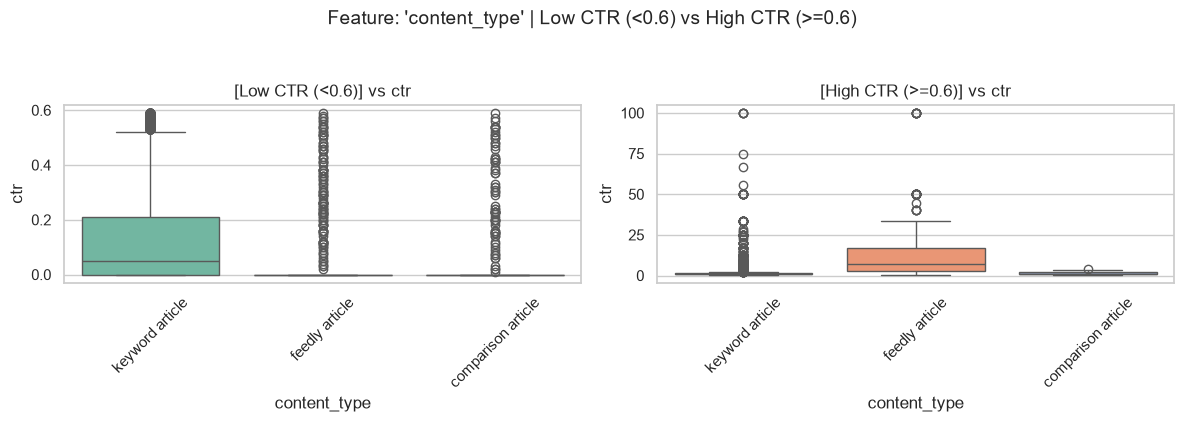

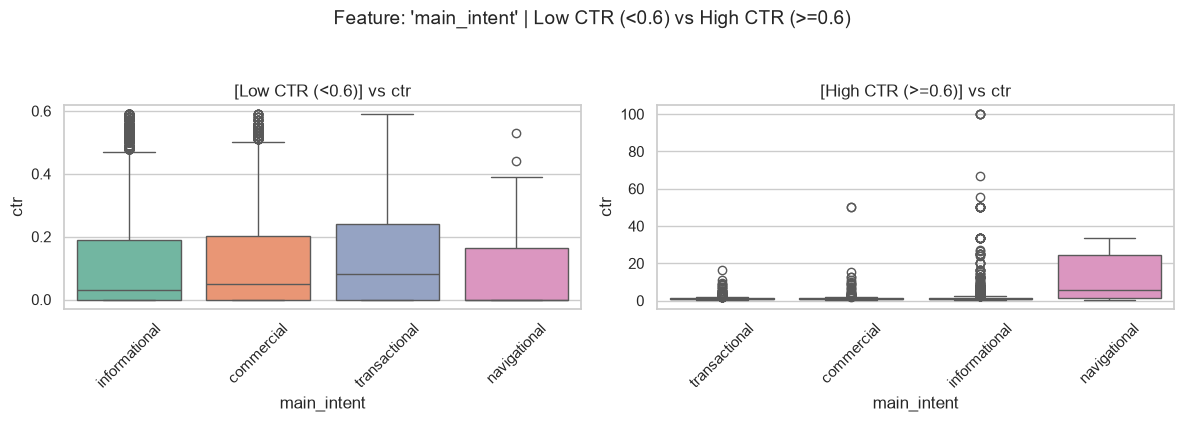

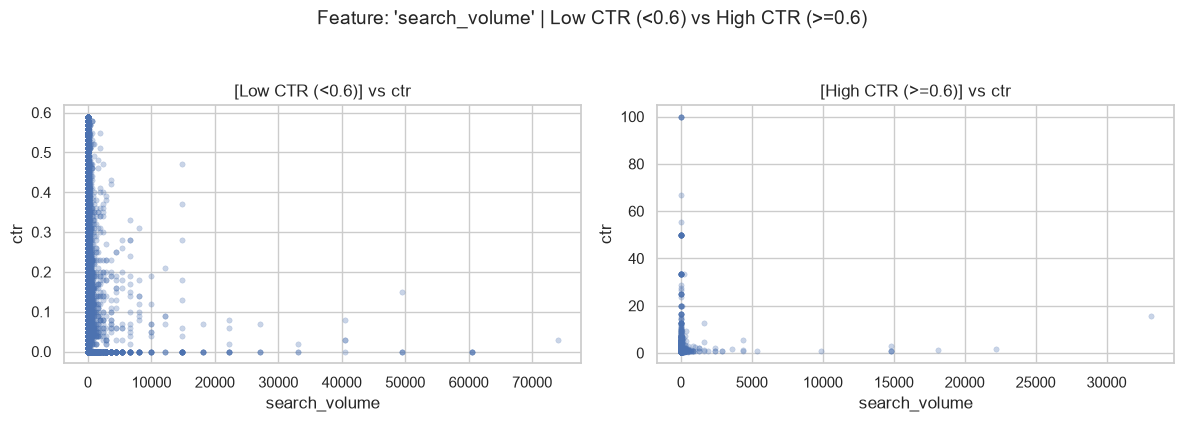

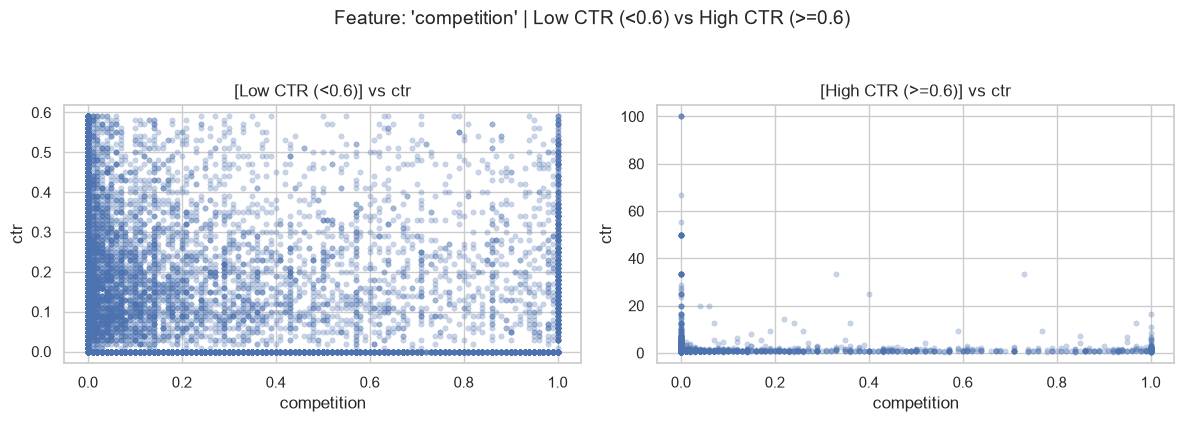

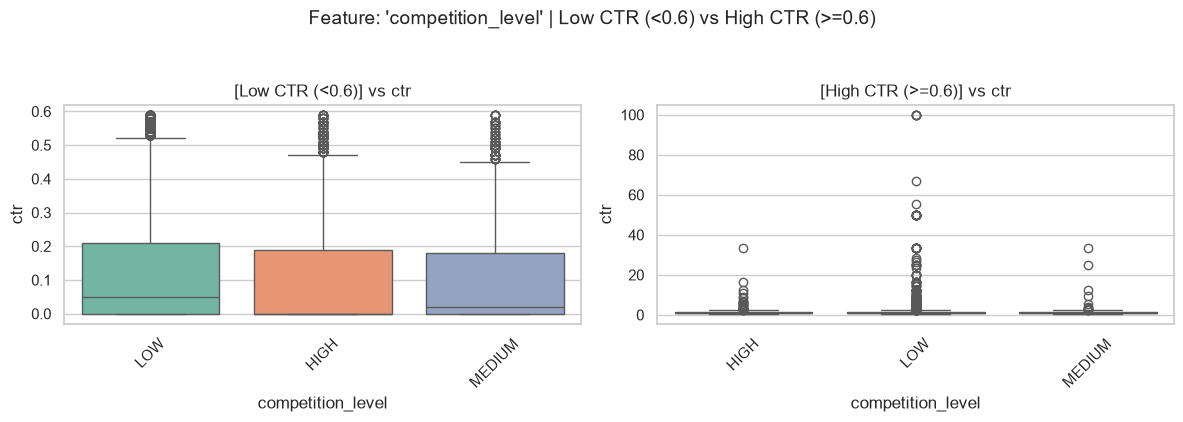

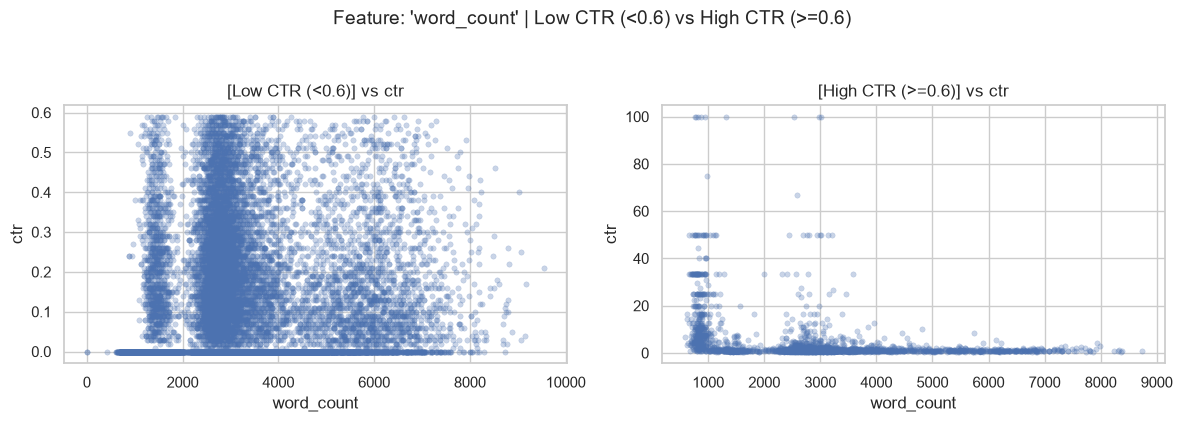

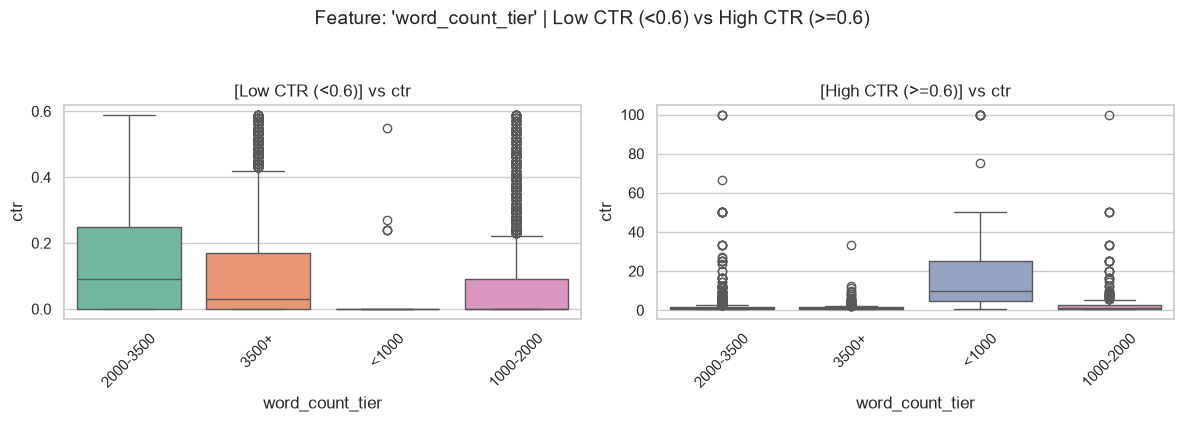

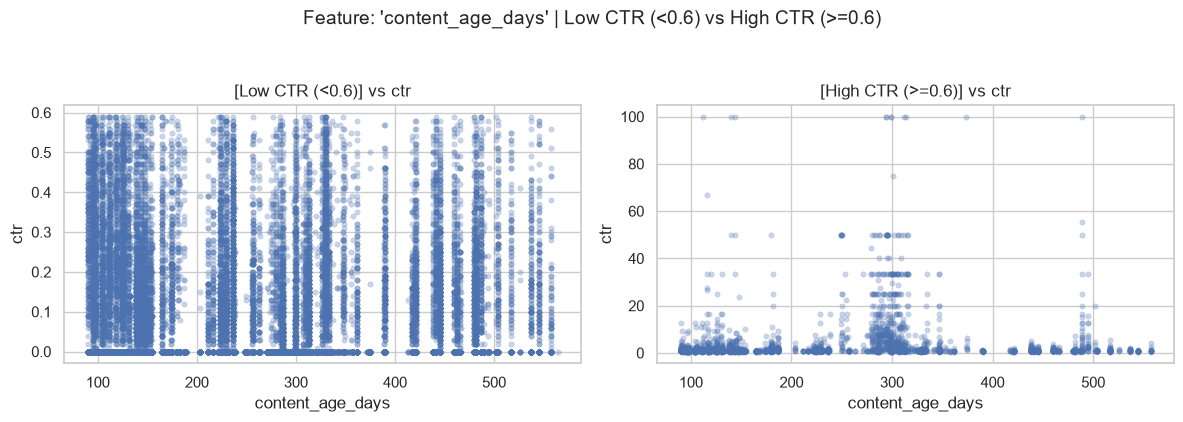

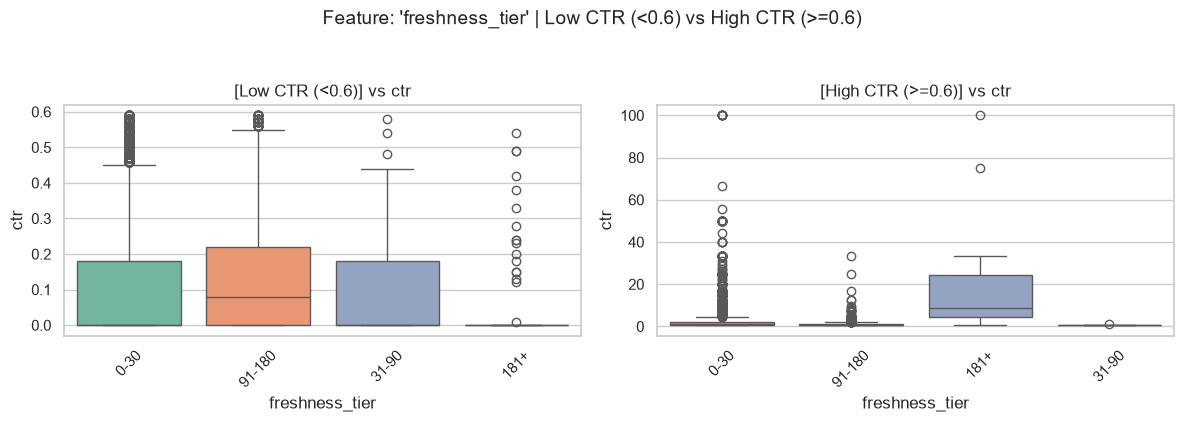

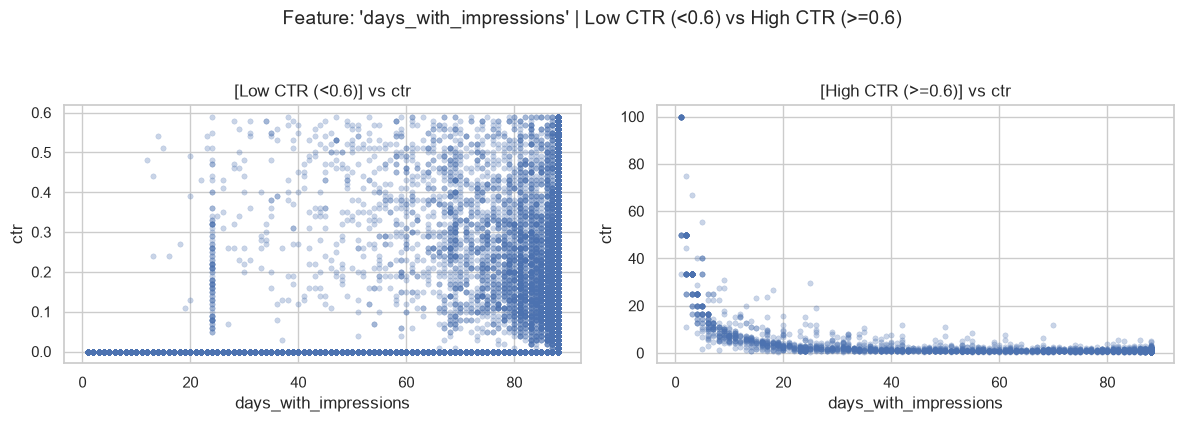

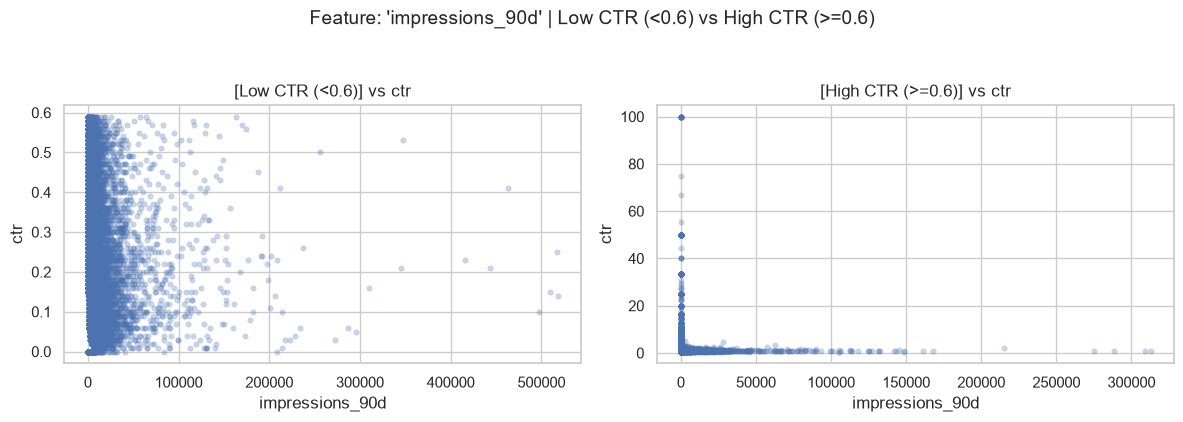

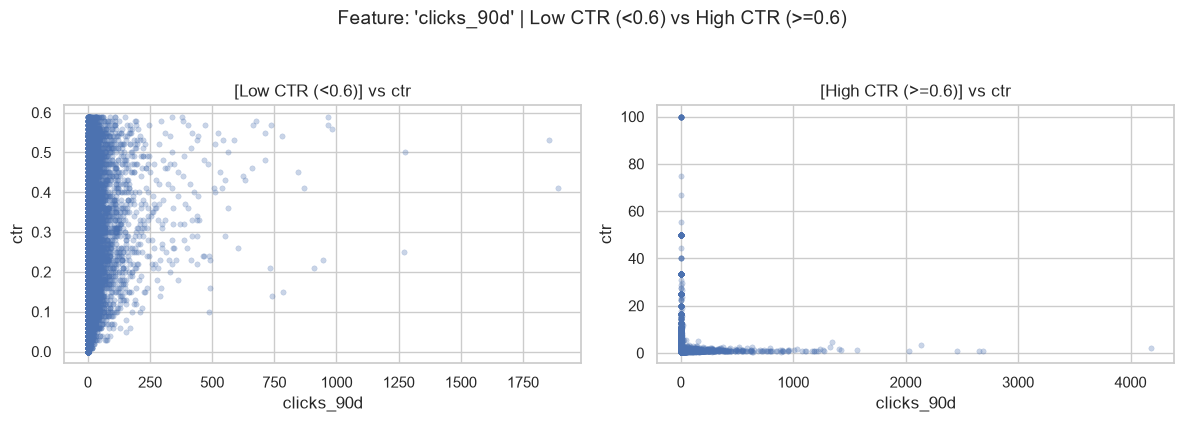

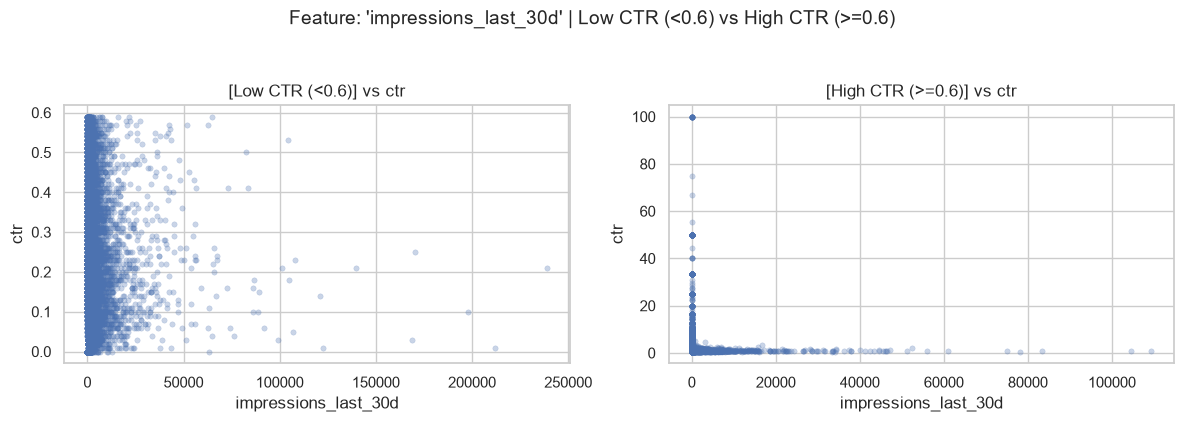

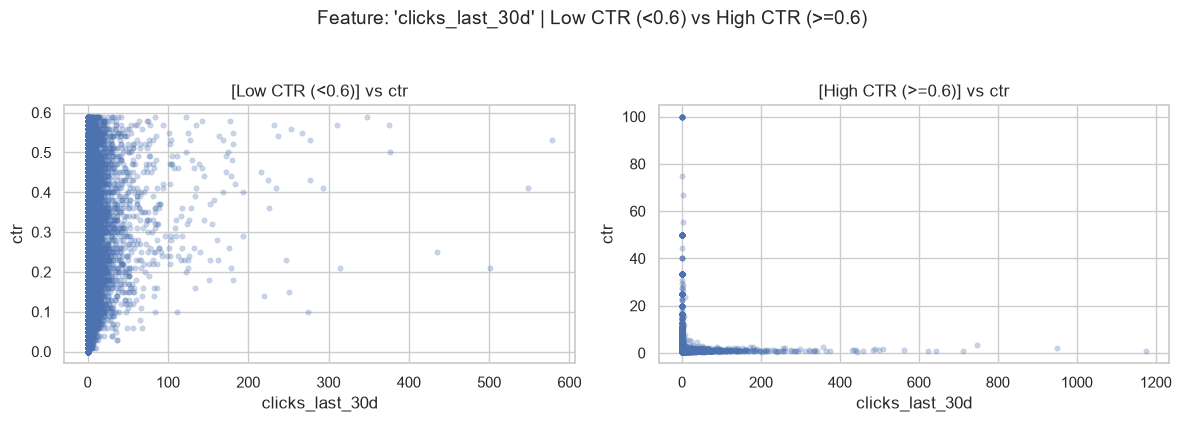

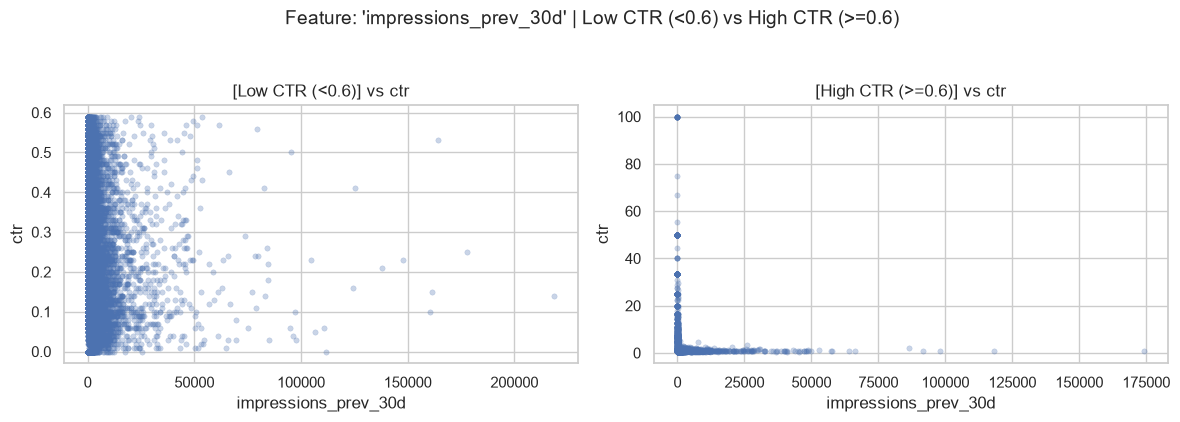

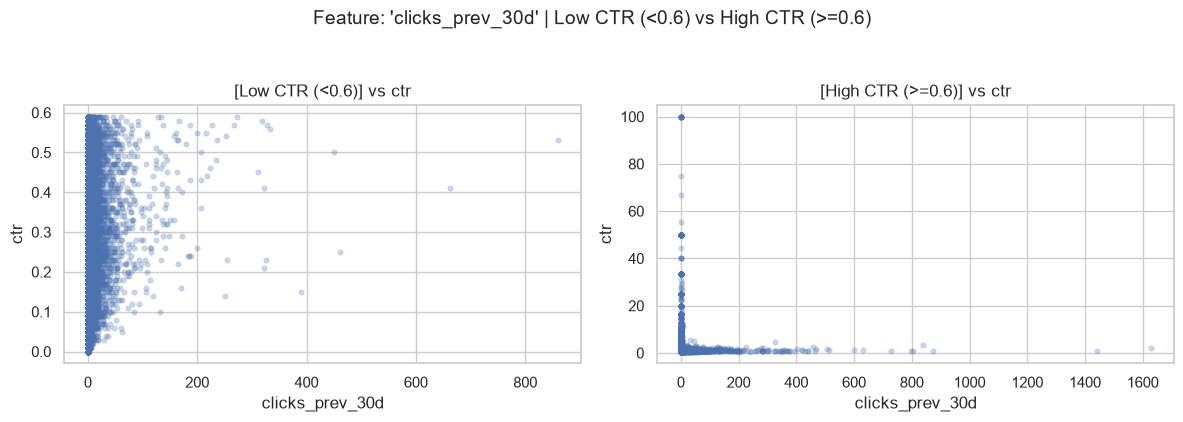

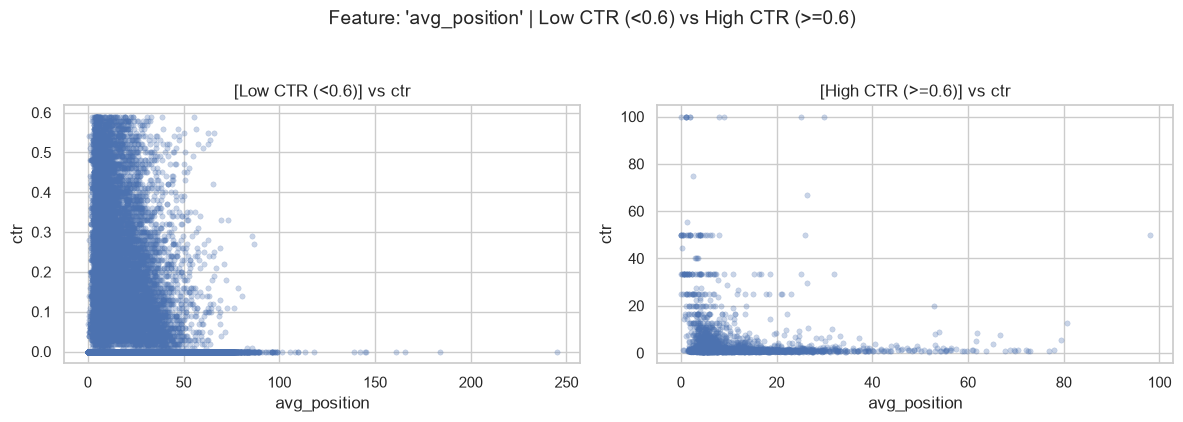

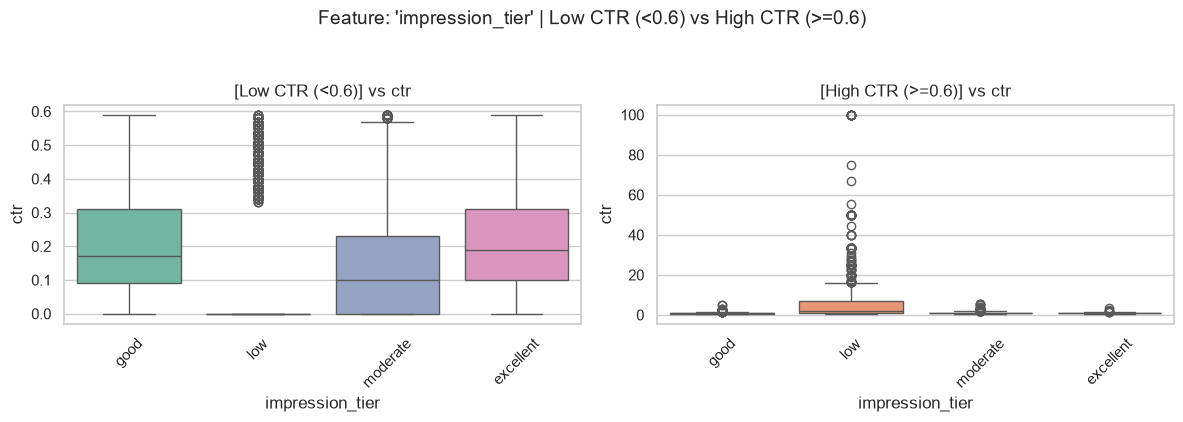

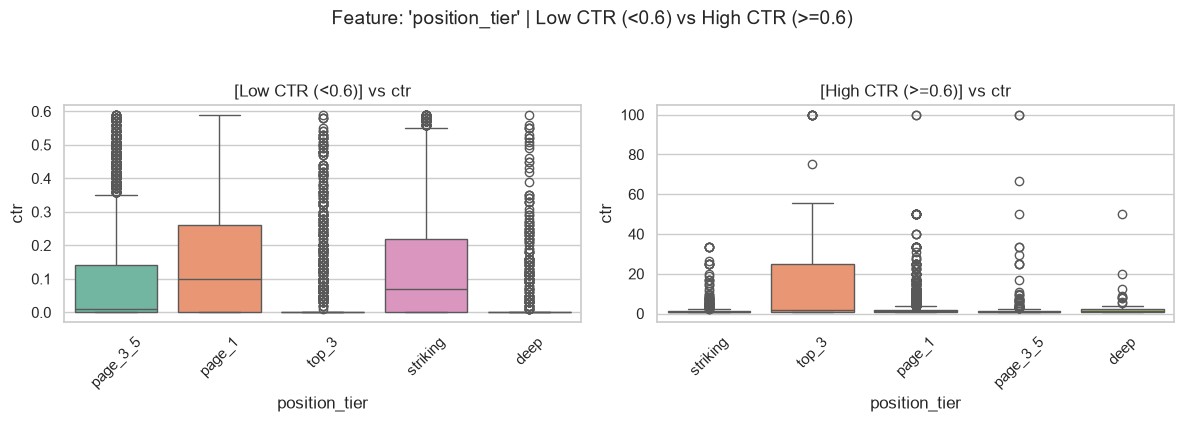

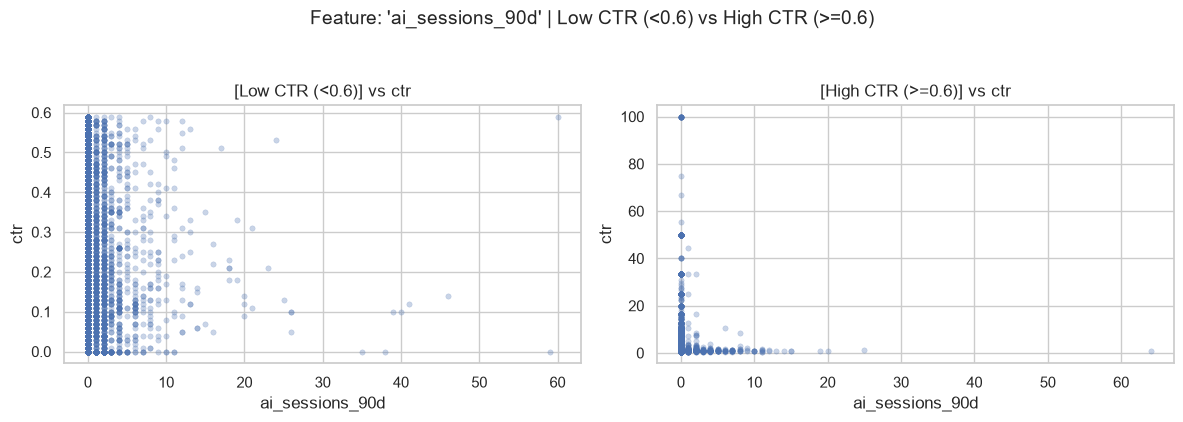

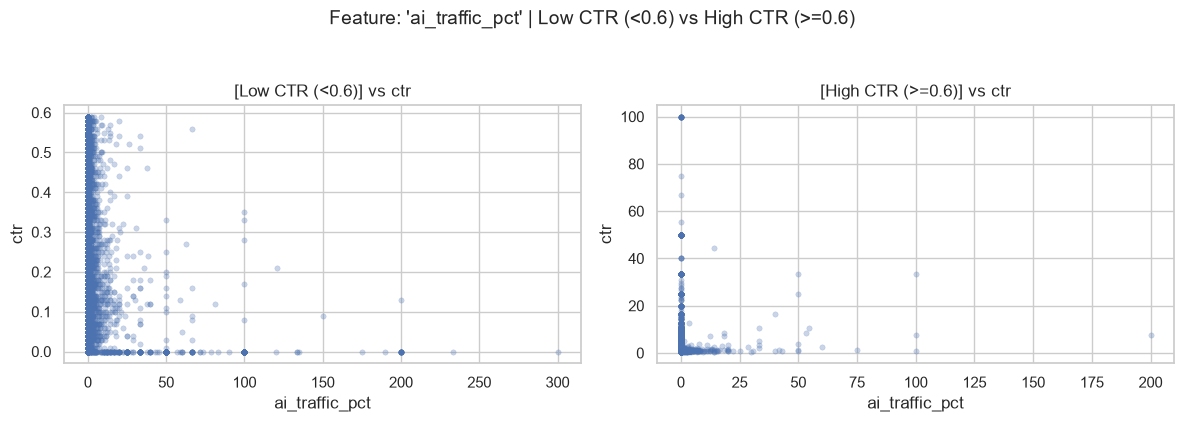

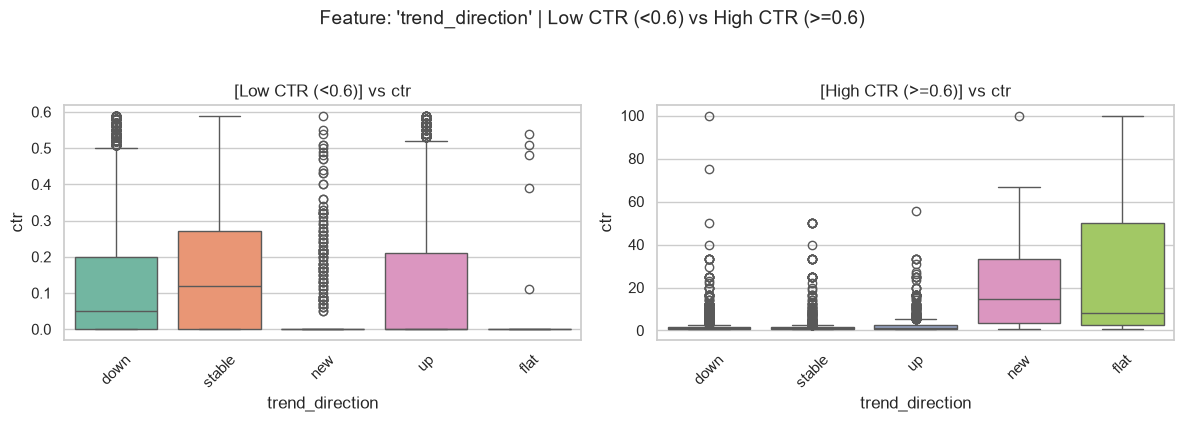

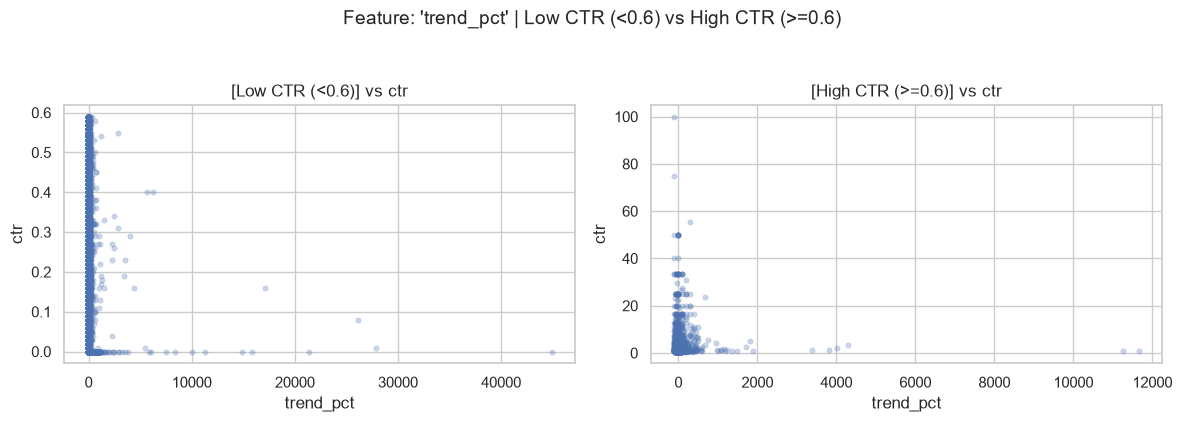

In [9]:
plot_features_vs_targets_side_by_side(
    df1=df_low_ctr, 
    df2=df_high_ctr, 
    label1="Low CTR (<0.6)", 
    label2="High CTR (>=0.6)", 
    feature_cols=feature_cols, 
    target_cols=target_cols
)

In [10]:
# Dictionary to store value counts for every categorical column
categorical_summary = {col: df[col].value_counts() for col in df.select_dtypes(include=['string', 'category'])}

# Example: View the summary for 'content_type'
print(categorical_summary.get('content_type'))
print(categorical_summary.get('trend_direction'))
print(categorical_summary.get('position_tier'))
print(categorical_summary.get('impression_tier'))
print(categorical_summary.get('word_count_tier'))
print(categorical_summary.get('freshness_tier'))
print(categorical_summary.get('content_type'))
print(categorical_summary.get('main_intent'))
print(categorical_summary.get('competition_level'))

content_type
keyword article       27207
feedly article         2096
comparison article      697
Name: count, dtype: int64
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64
position_tier
page_1      11814
striking     7304
page_3_5     7242
top_3        2321
deep         1319
Name: count, dtype: int64
impression_tier
low          11248
moderate     10469
good          7205
excellent     1078
Name: count, dtype: int64
word_count_tier
2000-3500    11263
3500+         6285
1000-2000     3780
<1000          973
Name: count, dtype: int64
freshness_tier
0-30      20480
91-180     9171
31-90       175
181+        174
Name: count, dtype: int64
content_type
keyword article       27207
feedly article         2096
comparison article      697
Name: count, dtype: int64
main_intent
informational    17235
transactional     5733
commercial        4612
navigational        46
Name: count, dtype: int64
competition_level
LOW       228

In [15]:
df_low_eng=df_engagement[(df_engagement['engagement_rate']<3)& (df_engagement['scroll_rate']<18)]
df_high_eng=df_engagement[(df_engagement['engagement_rate']>=3)& (df_engagement['scroll_rate']>=18)]

feature_cols = ['content_type', 'main_intent',
       'provider_used', 'model_used', 'word_count', 'char_count',
       'word_count_tier', 'char_count_tier', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d',
       'scroll_events_90d', 'days_with_sessions', 'sessions_last_30d',
       'sessions_prev_30d',
       'ai_sessions_90d', 'ai_traffic_pct', 'trend_direction', 'trend_pct']
target_cols = ['engagement_rate', 'scroll_rate']

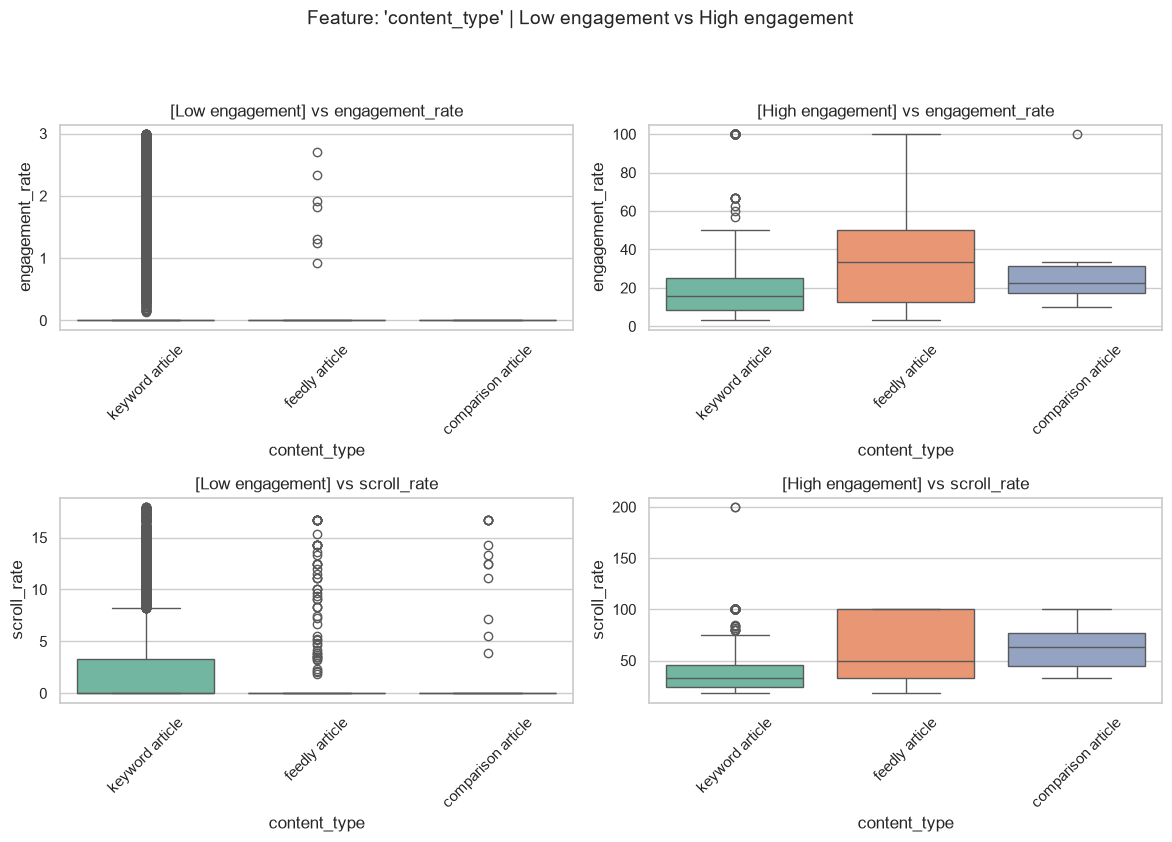

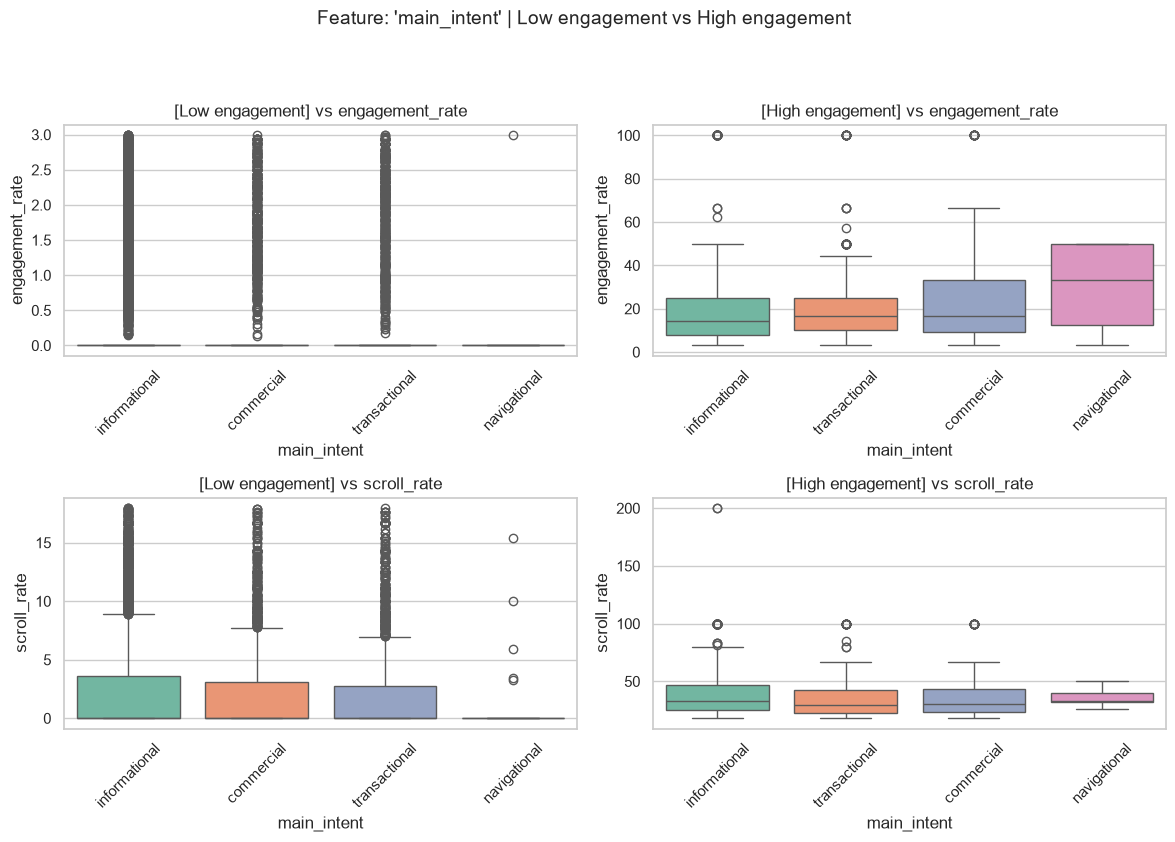

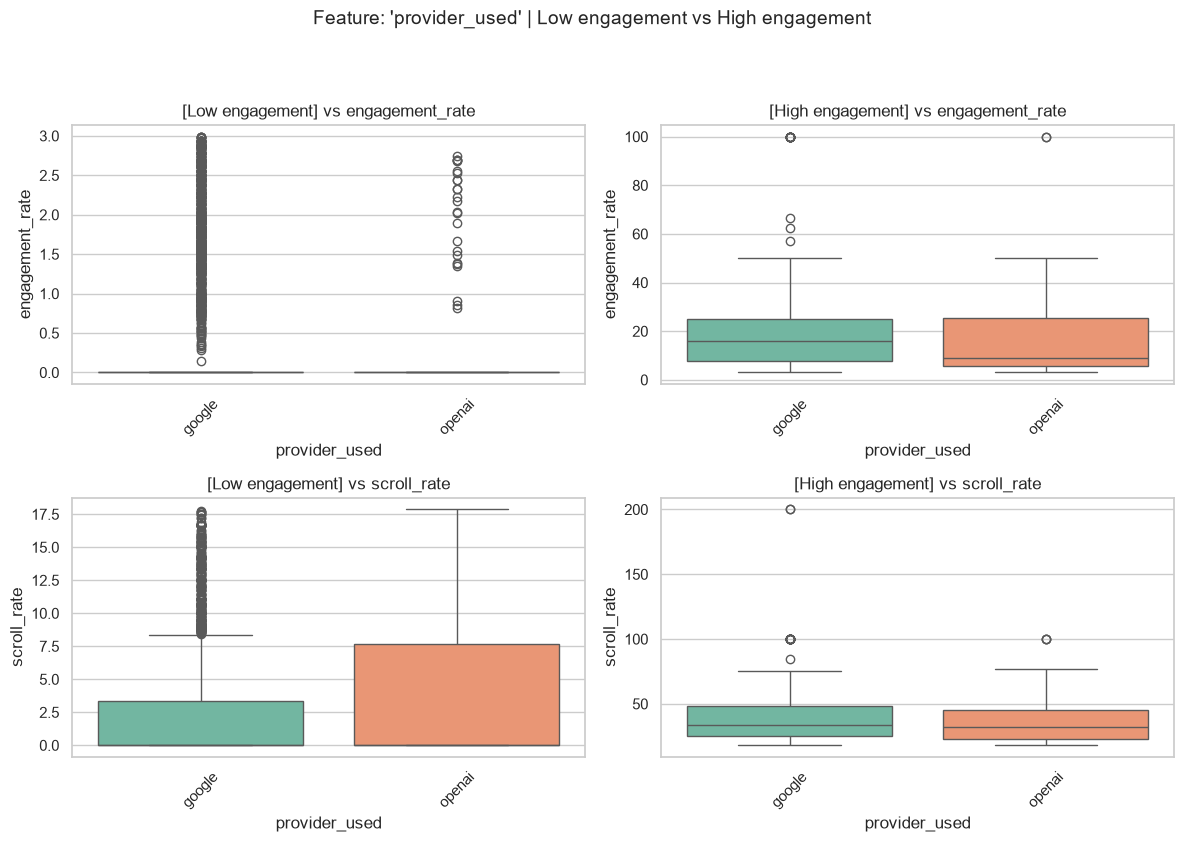

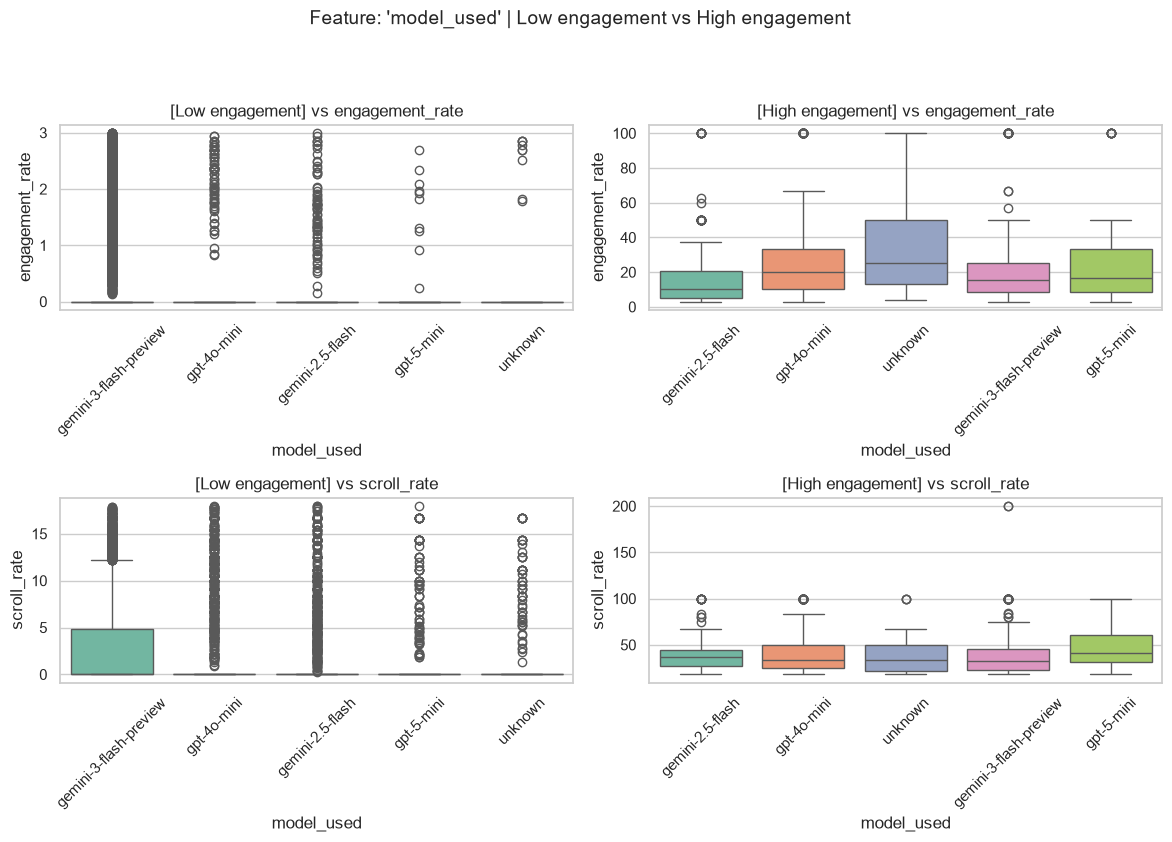

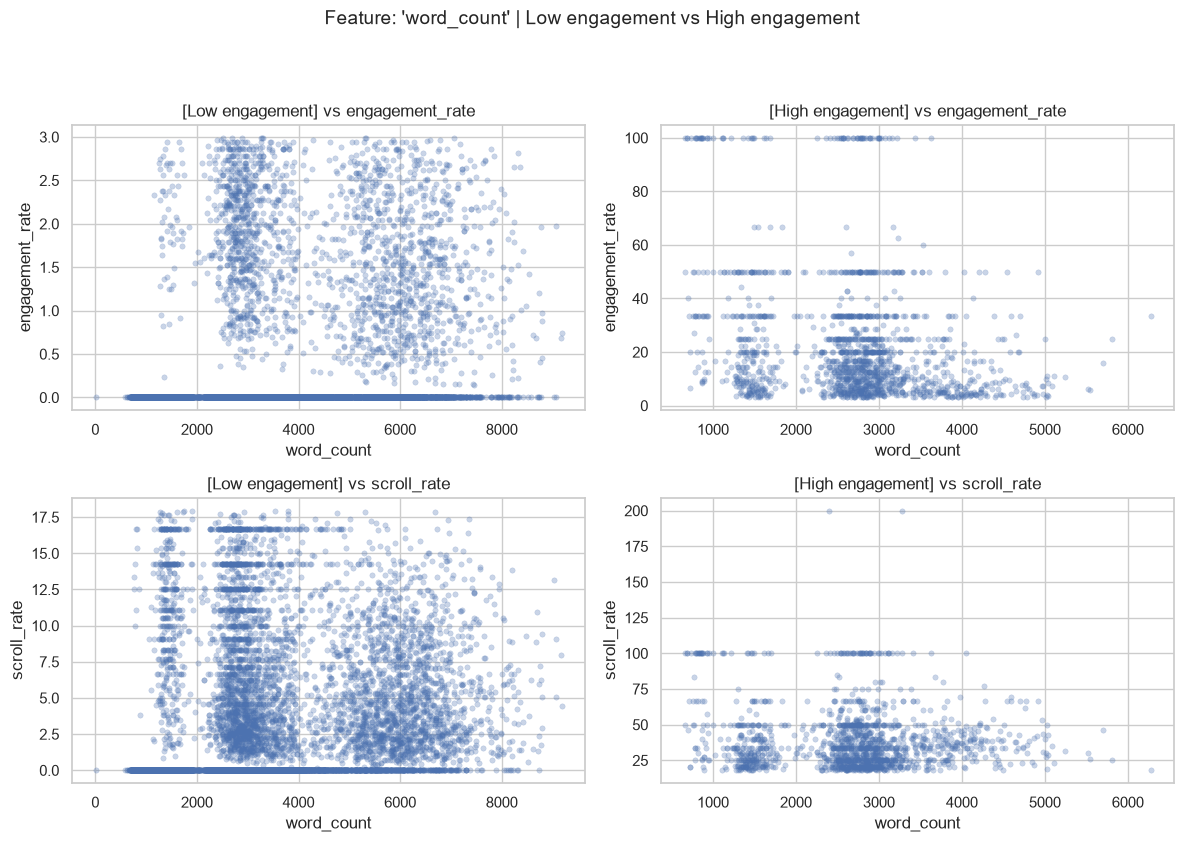

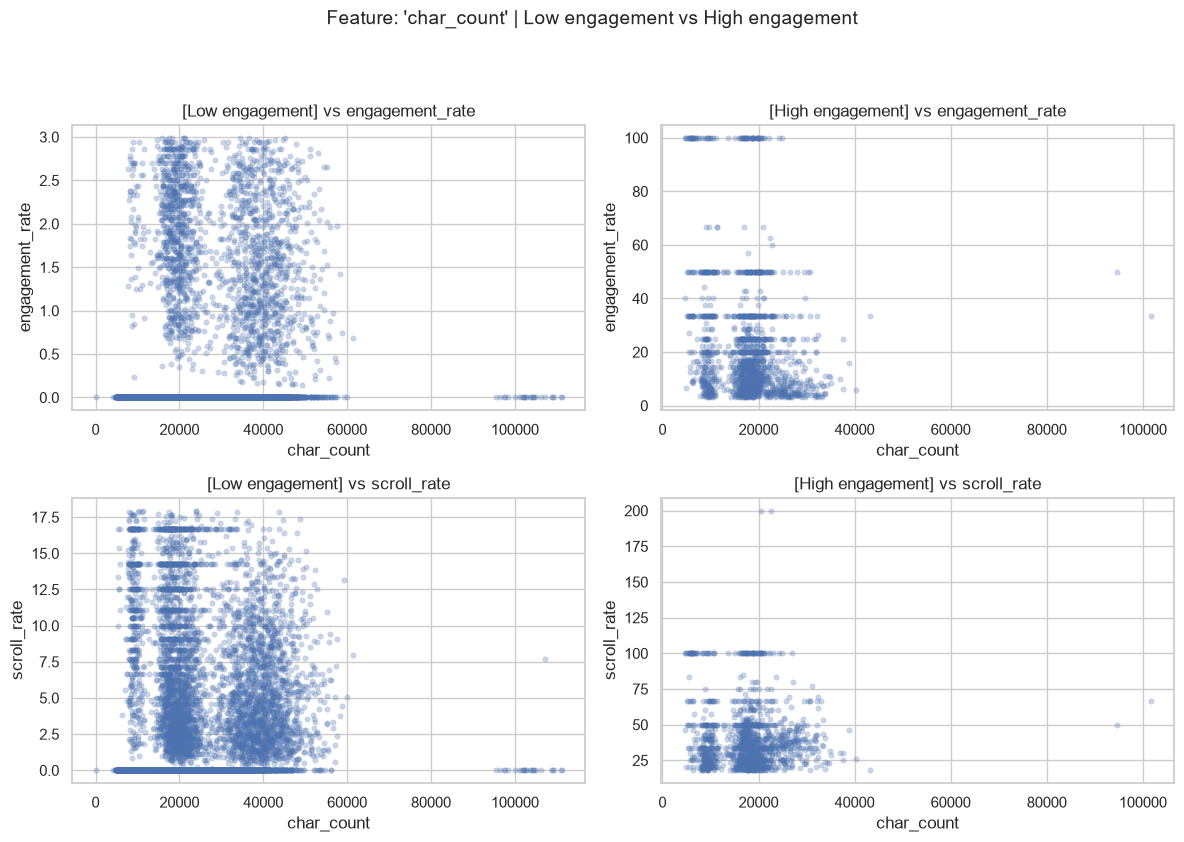

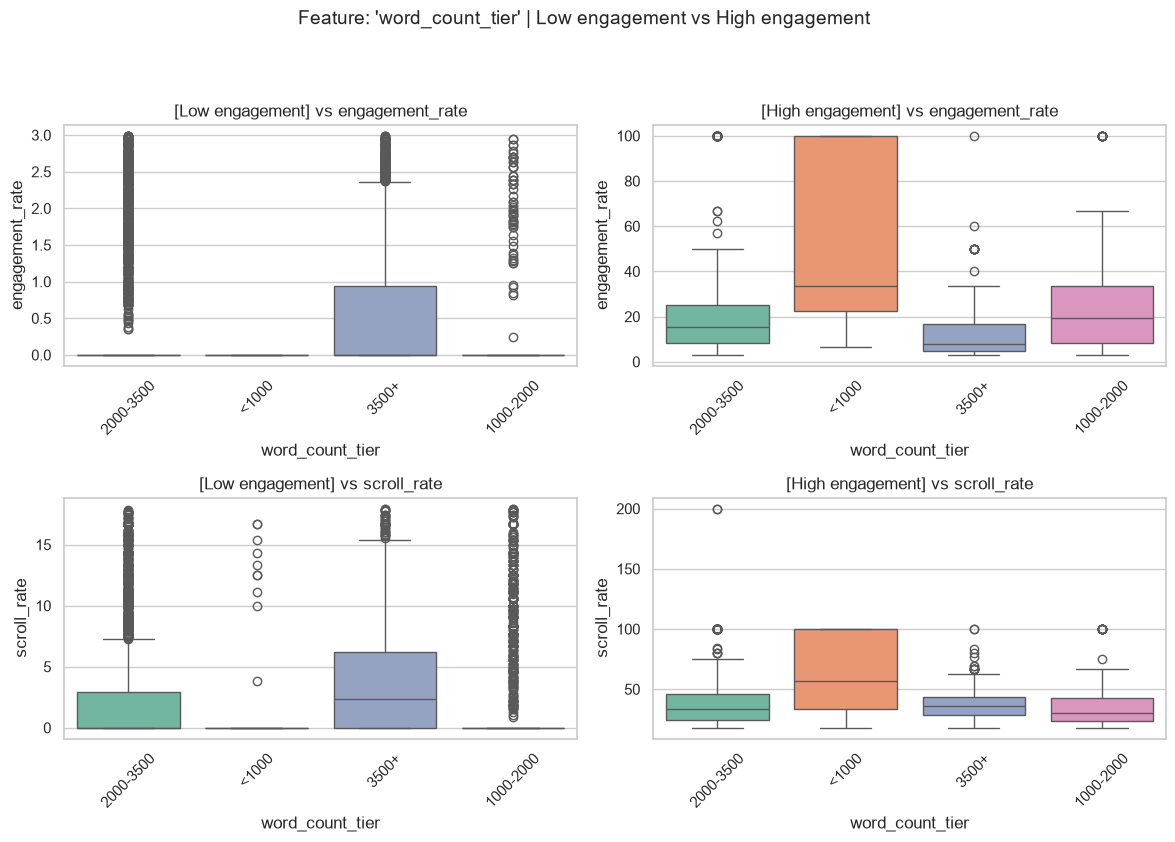

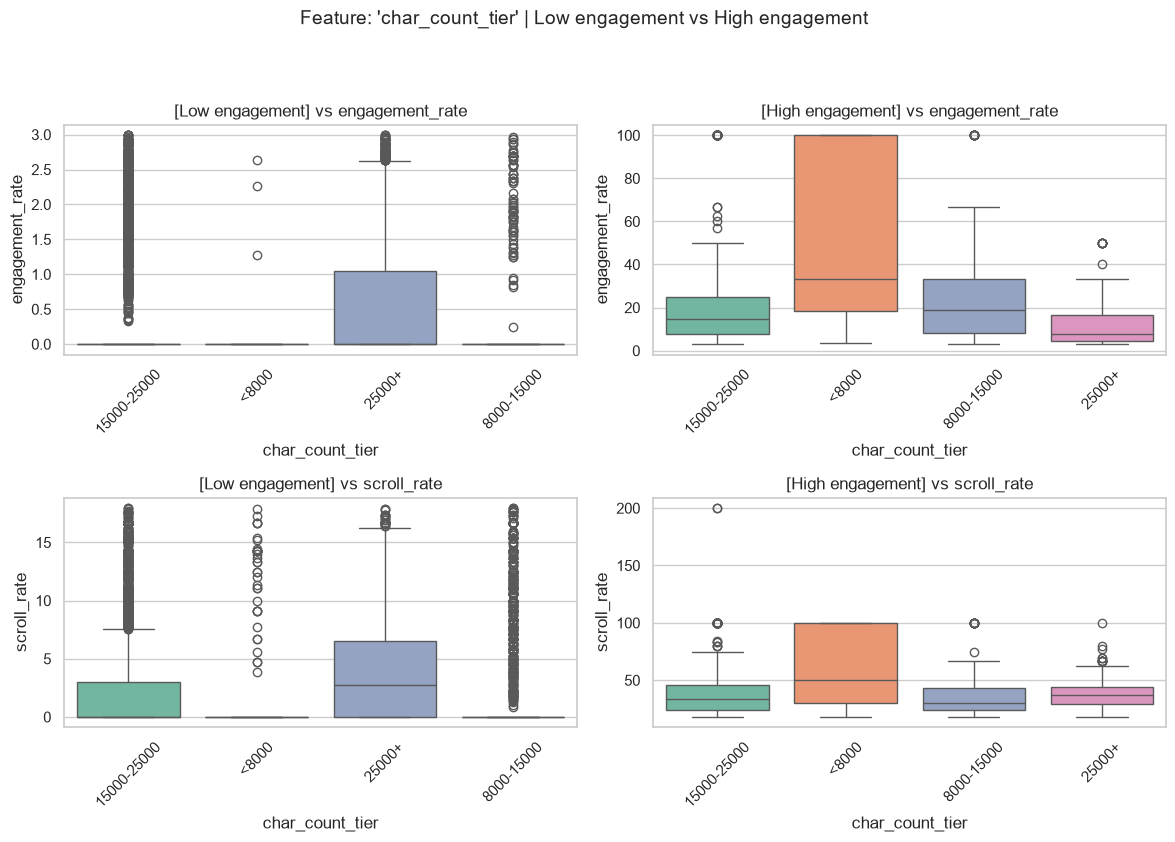

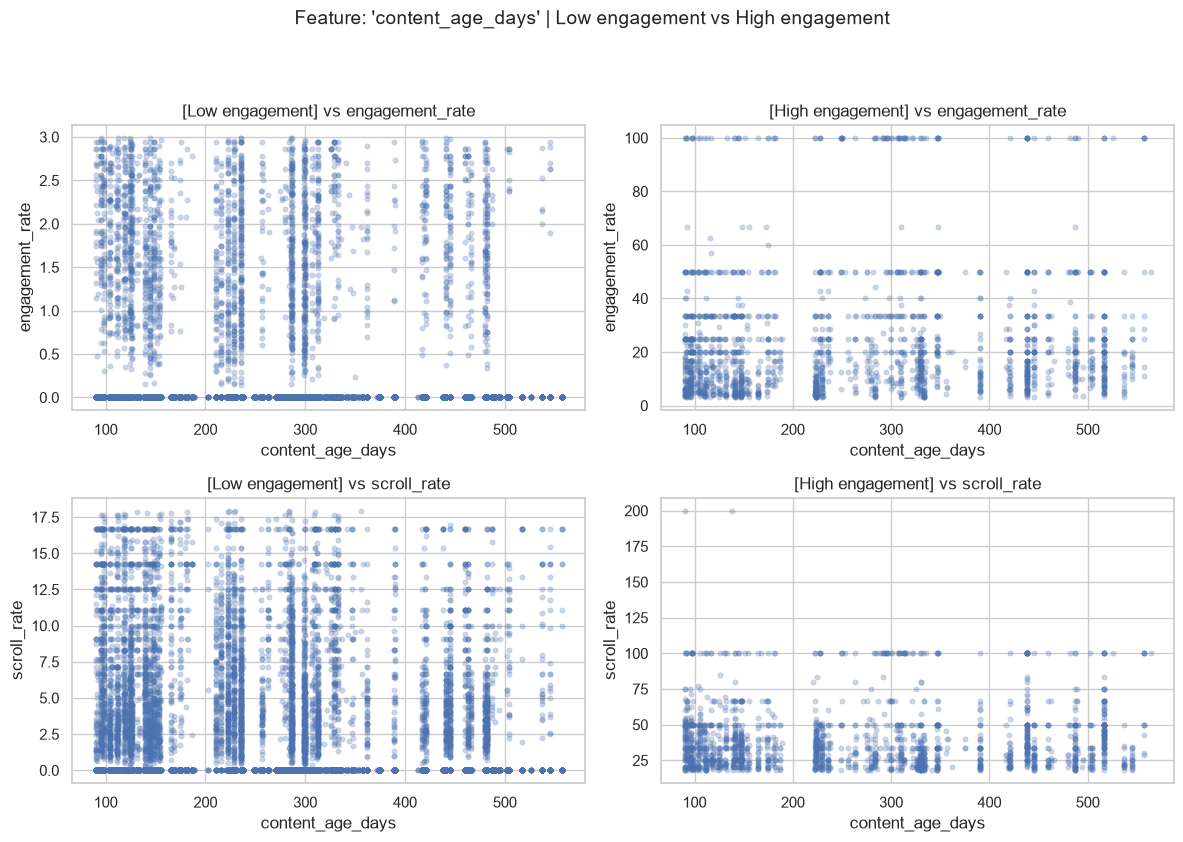

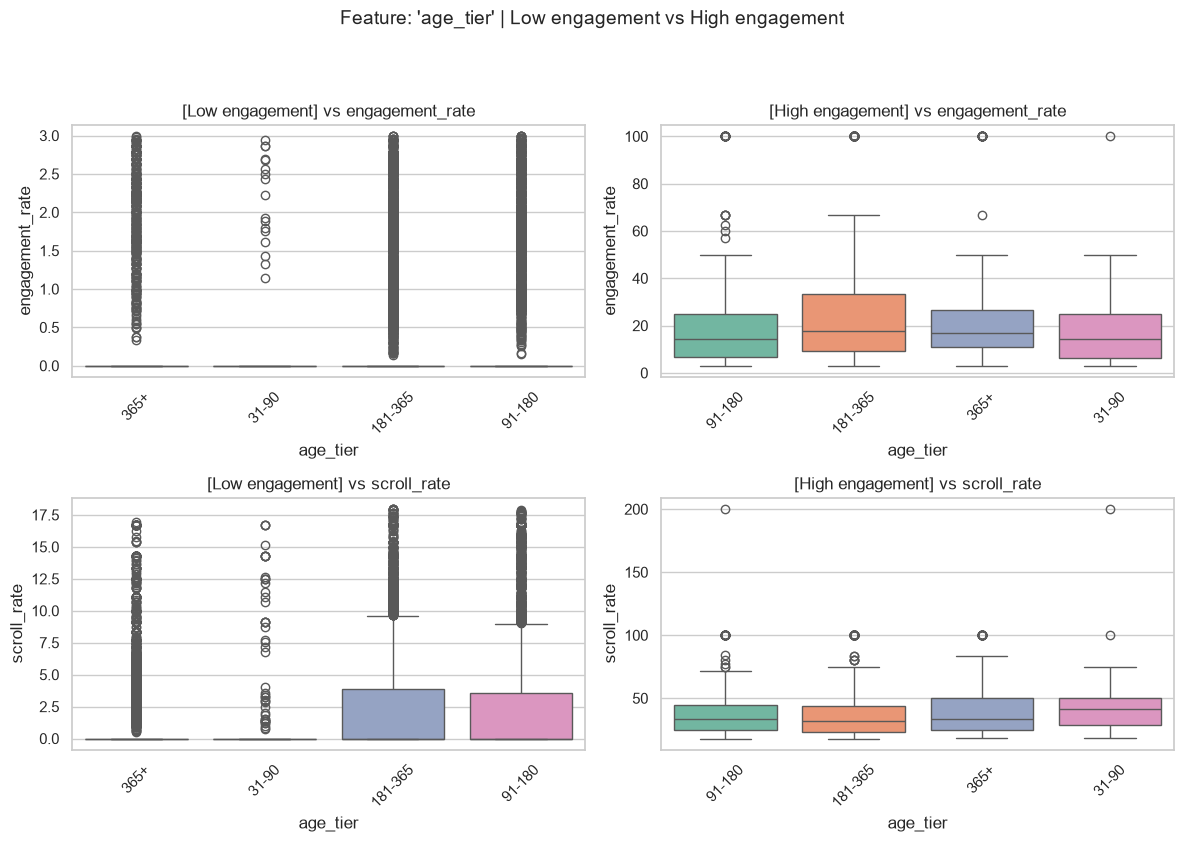

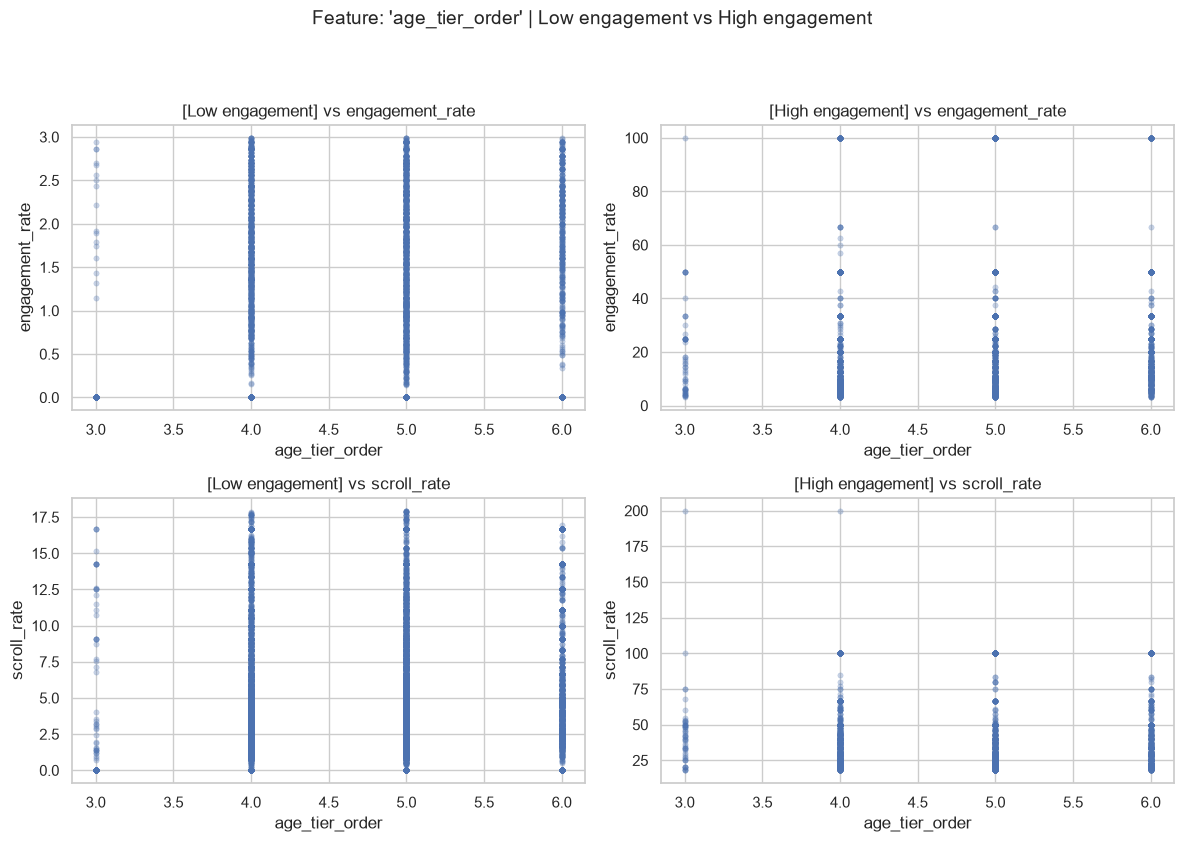

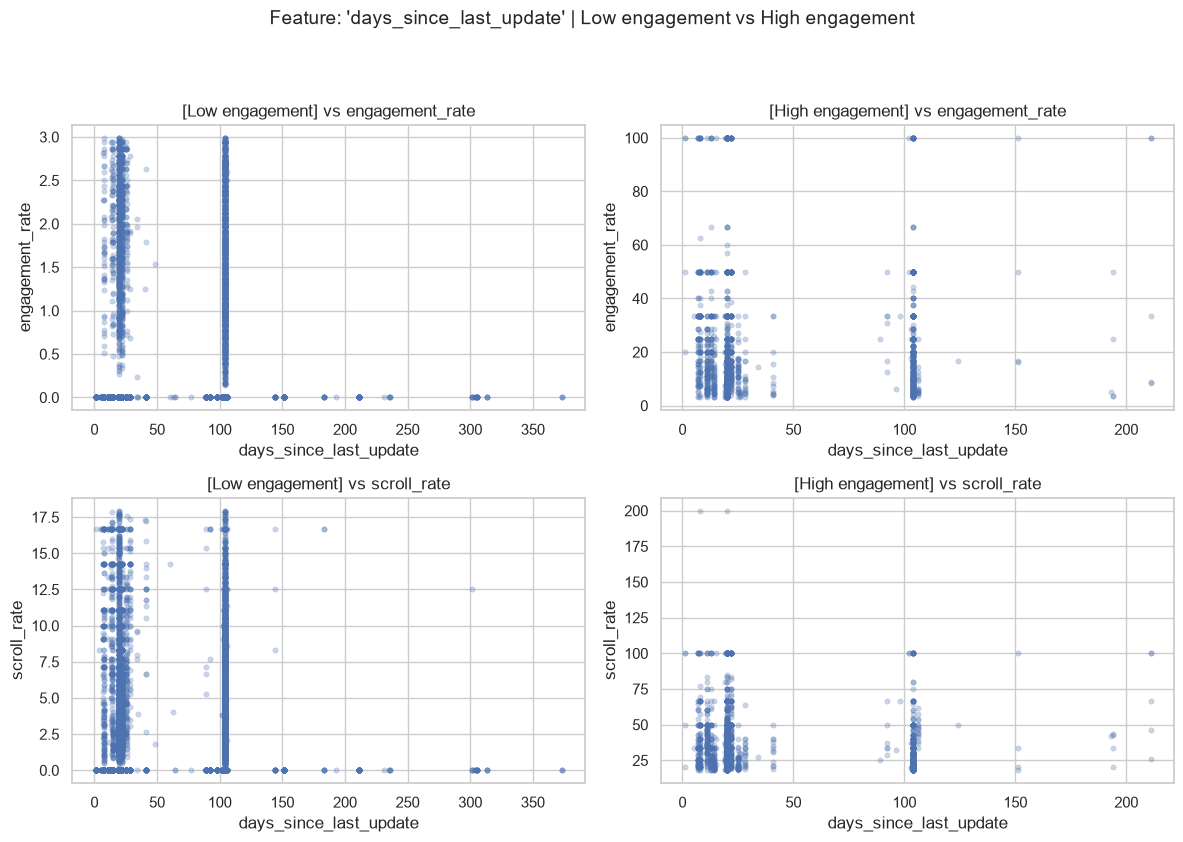

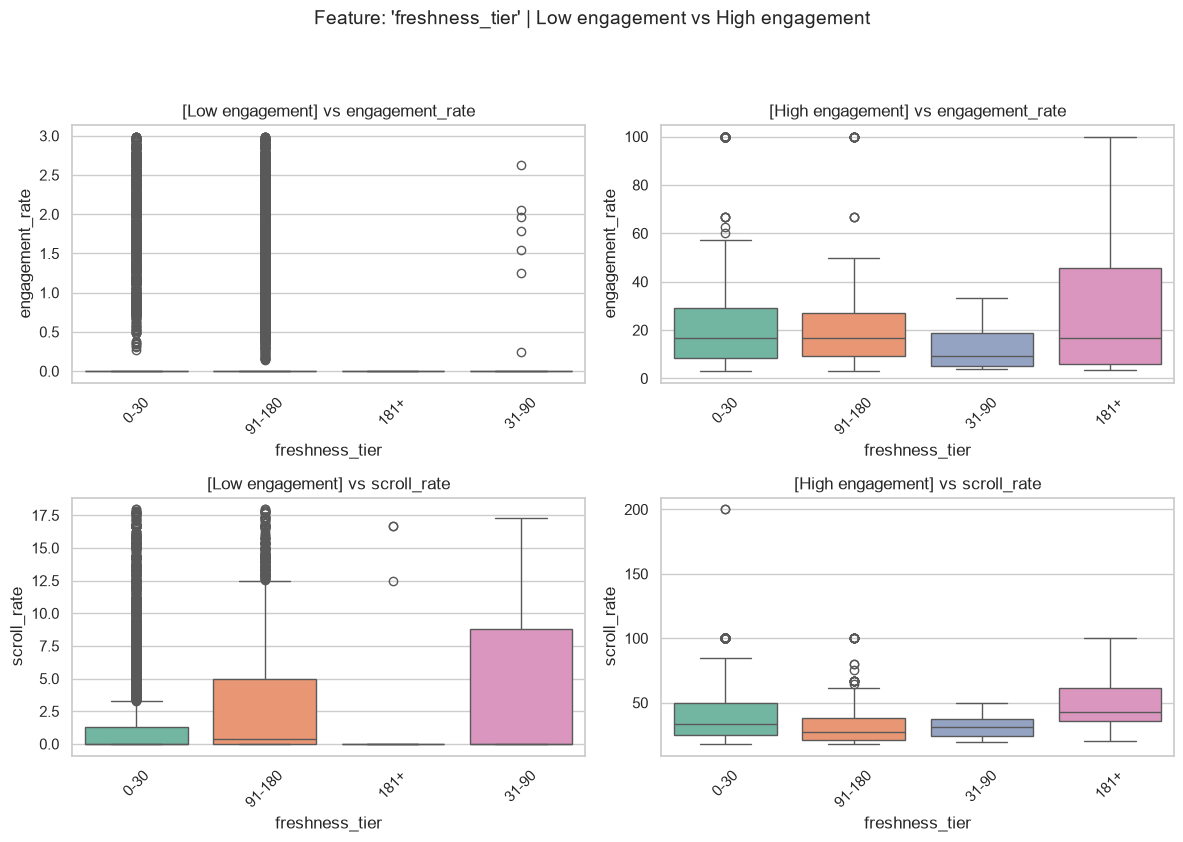

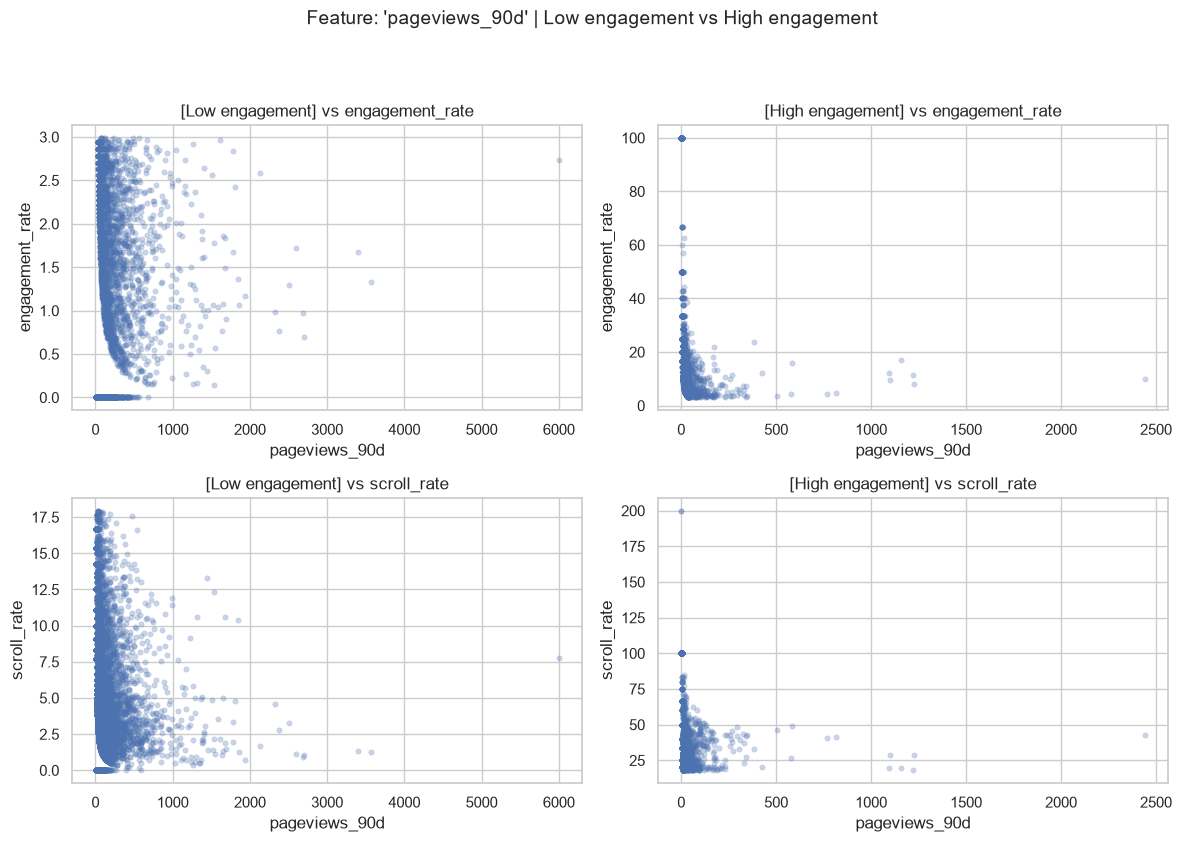

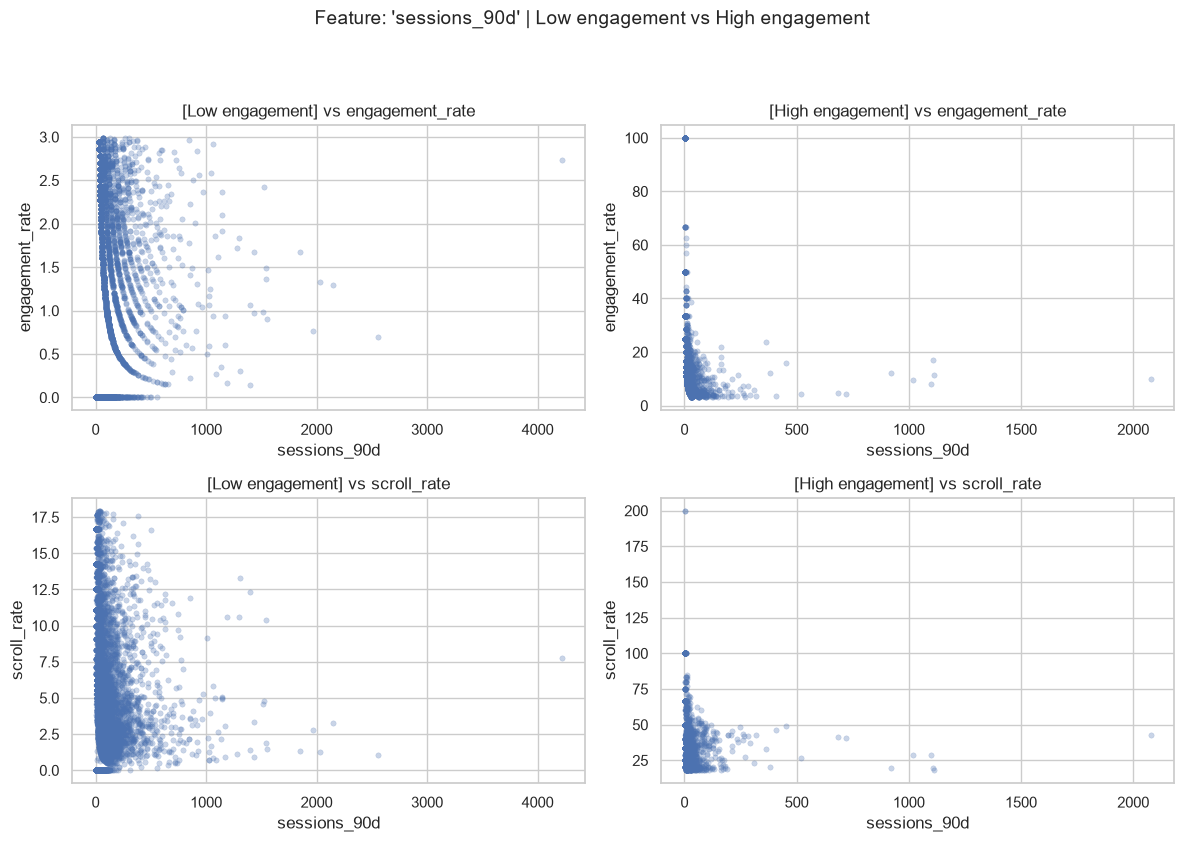

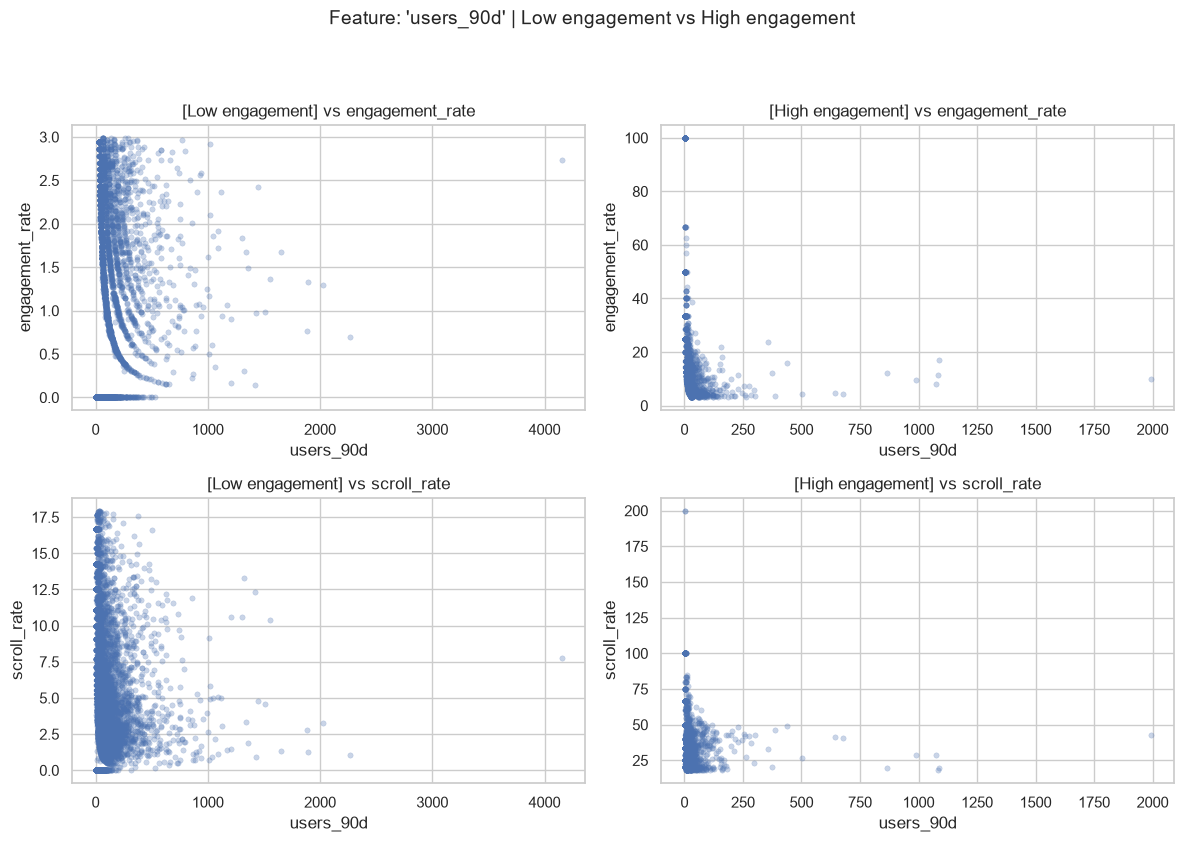

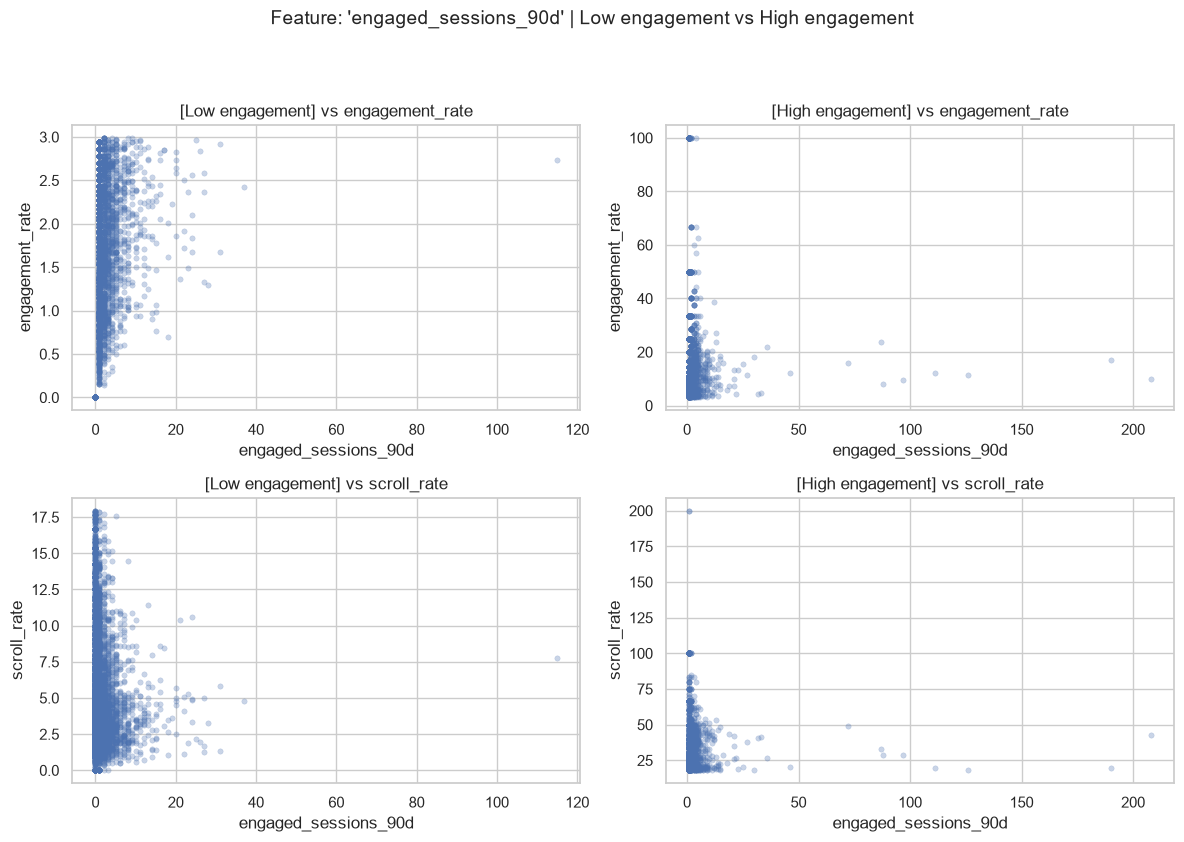

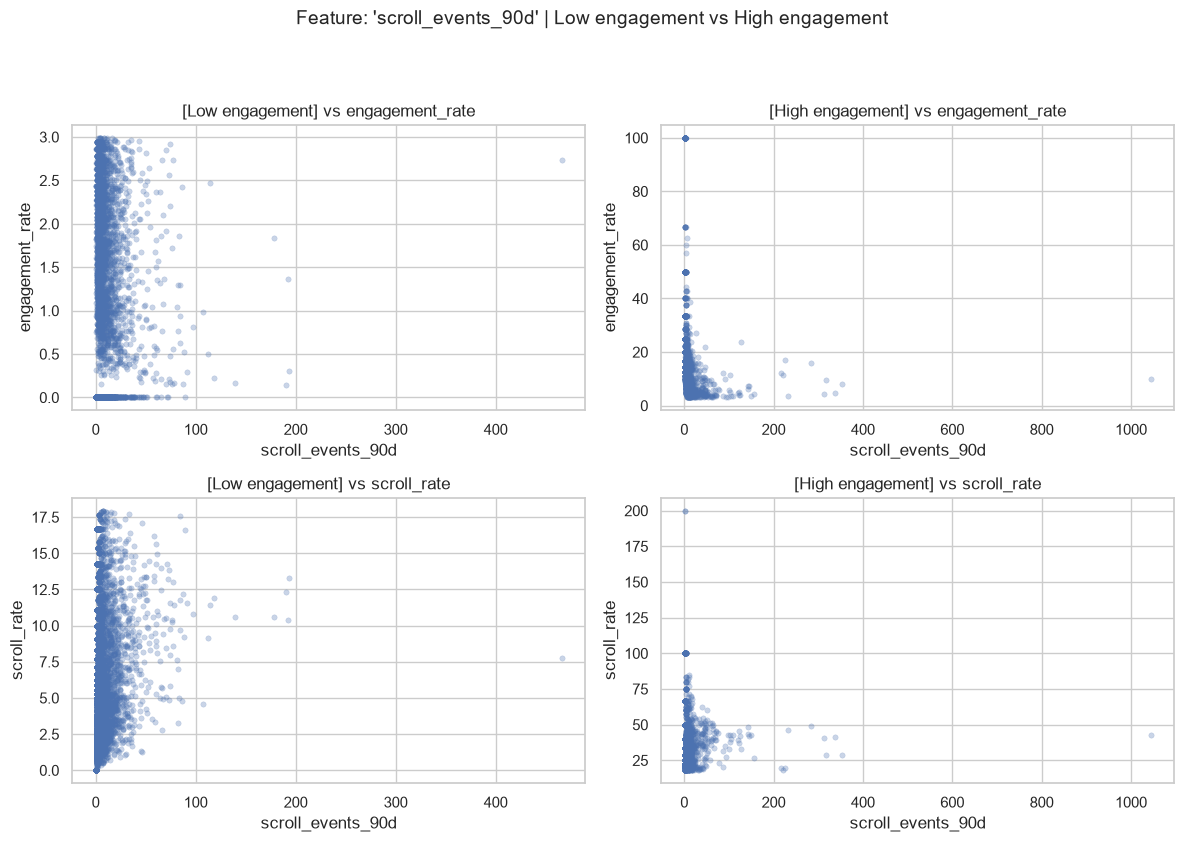

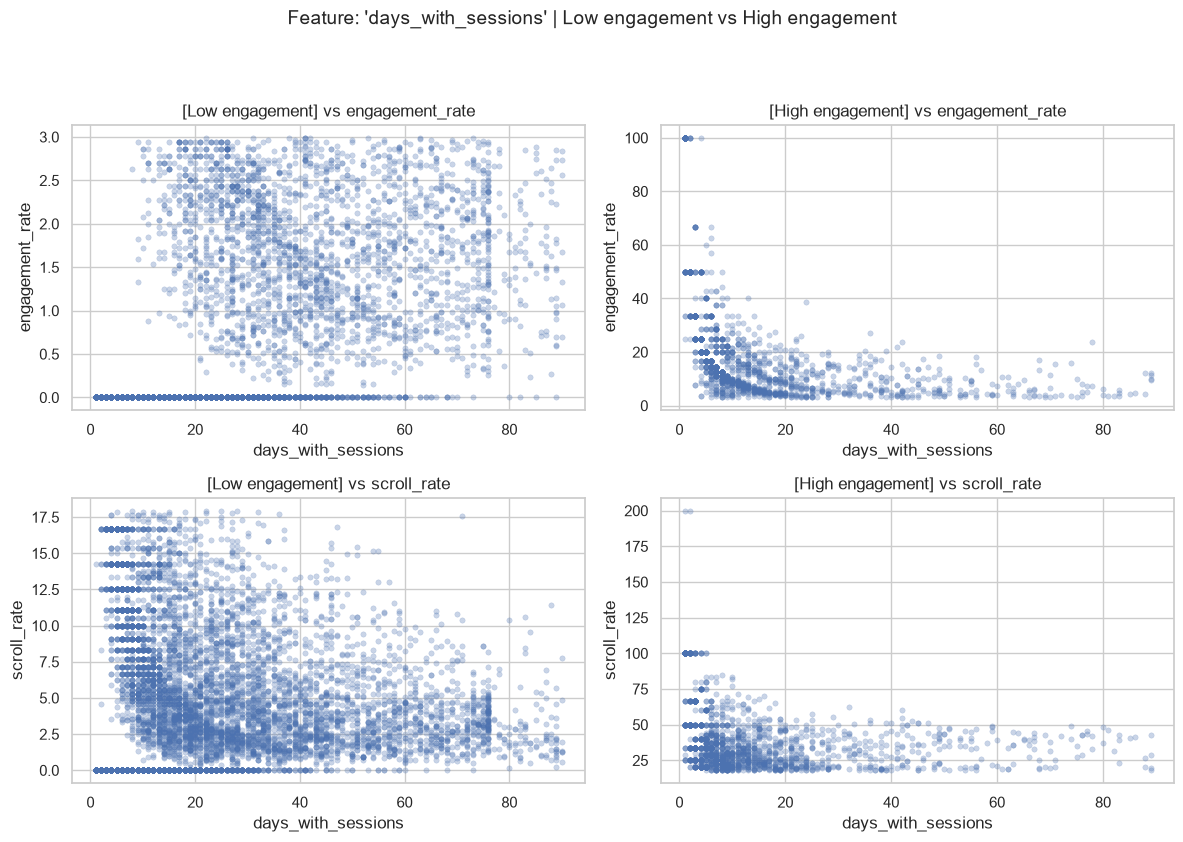

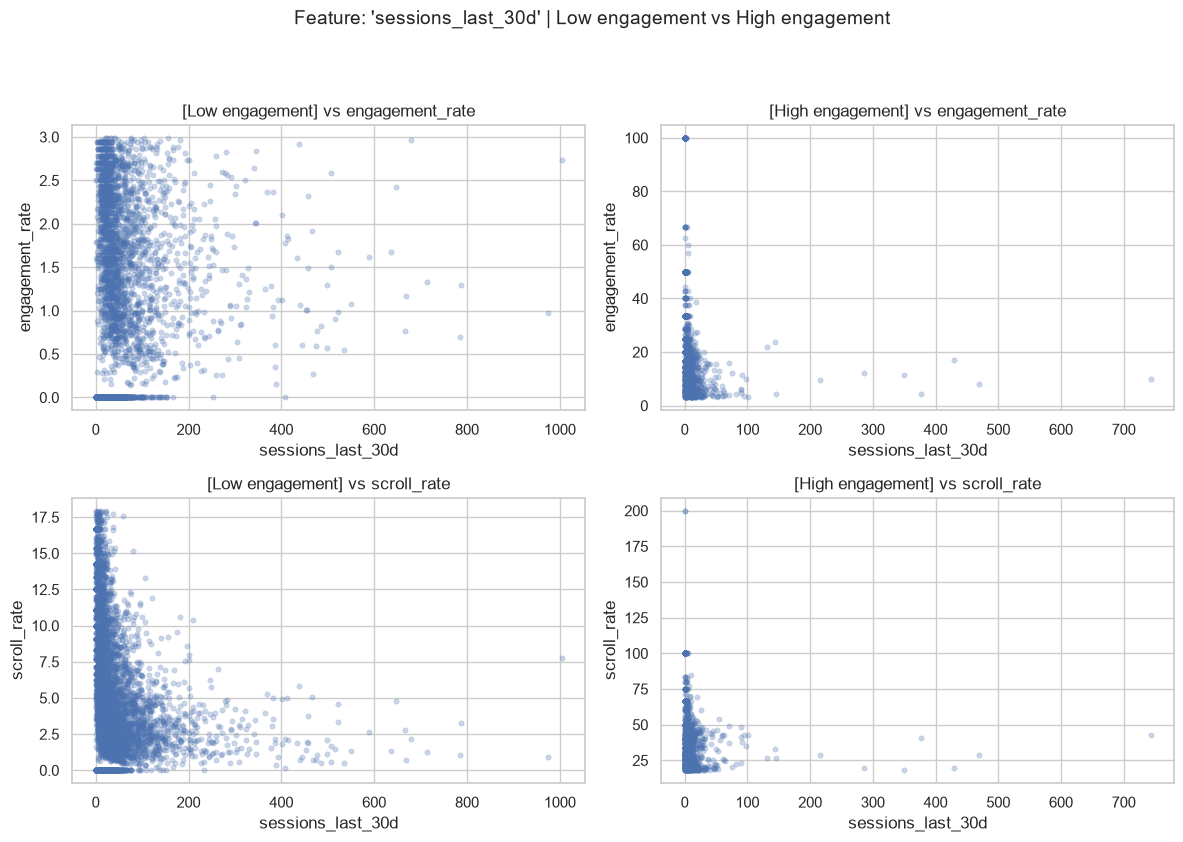

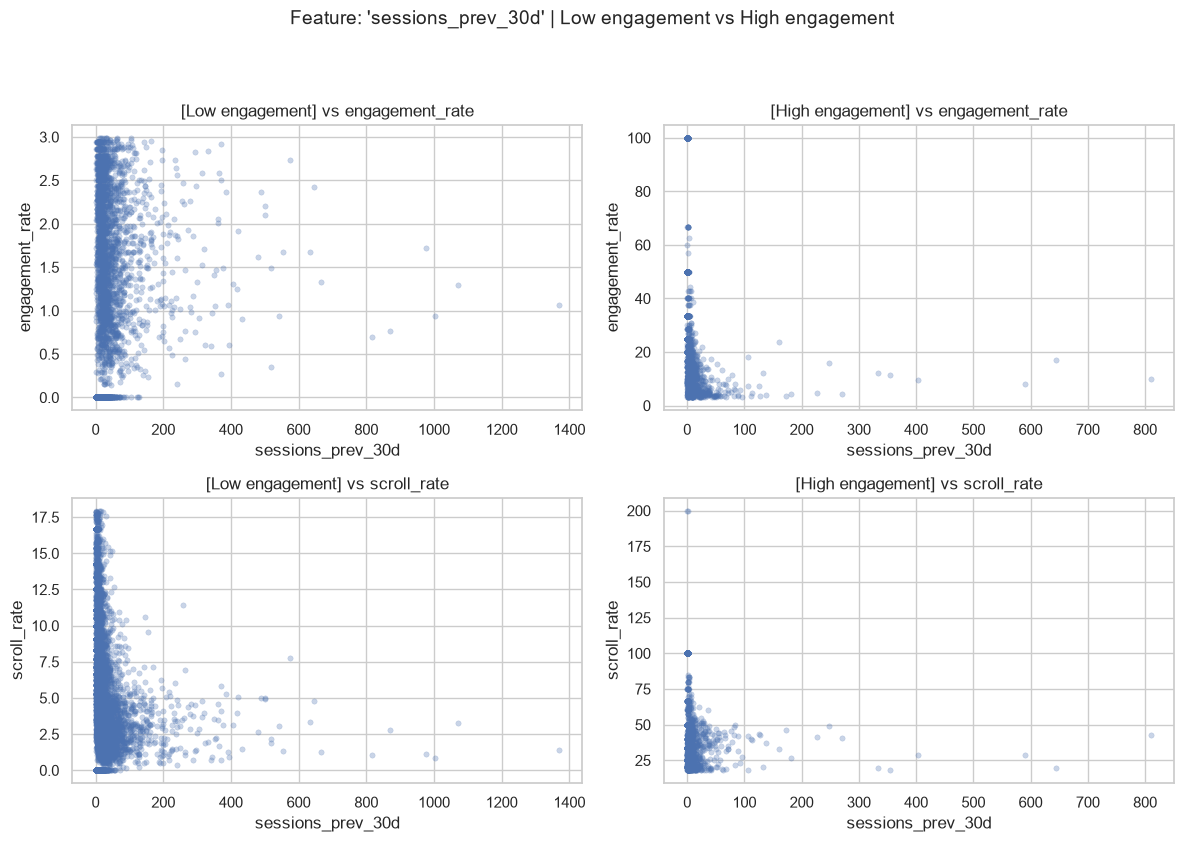

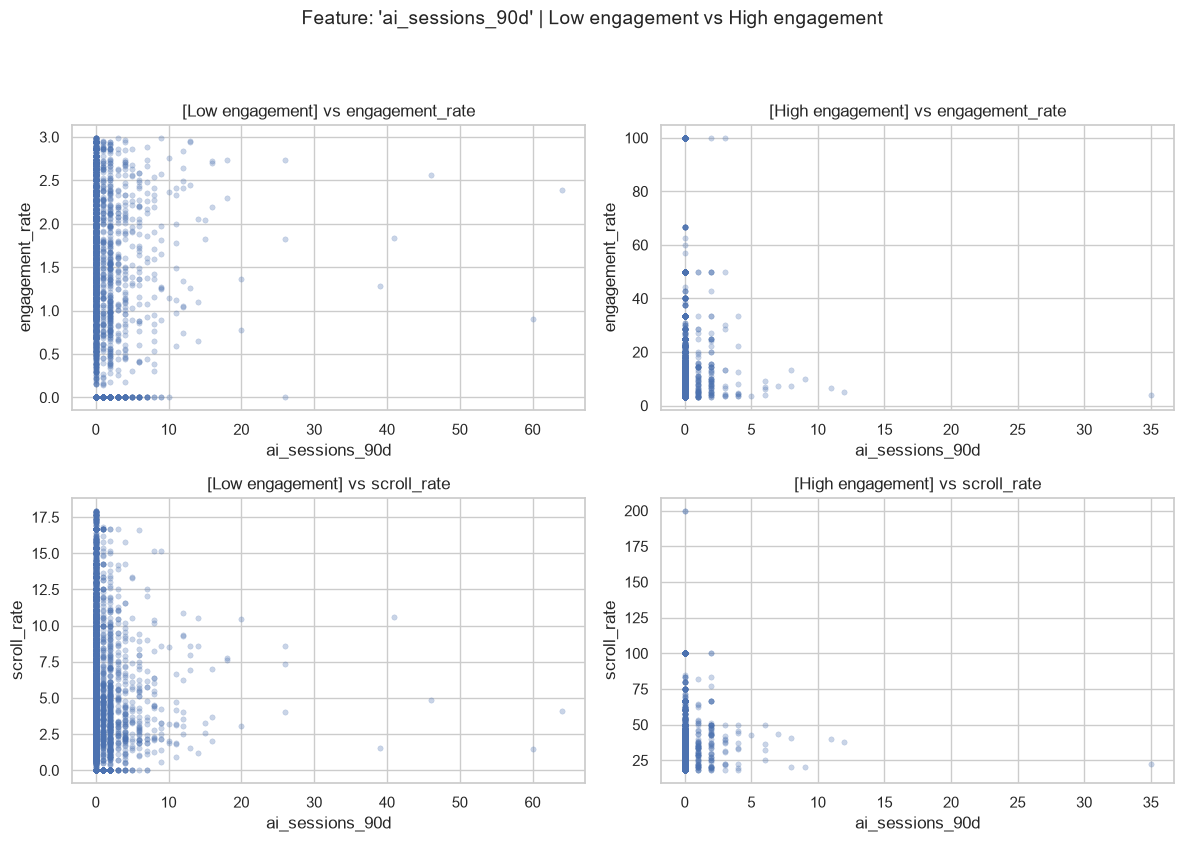

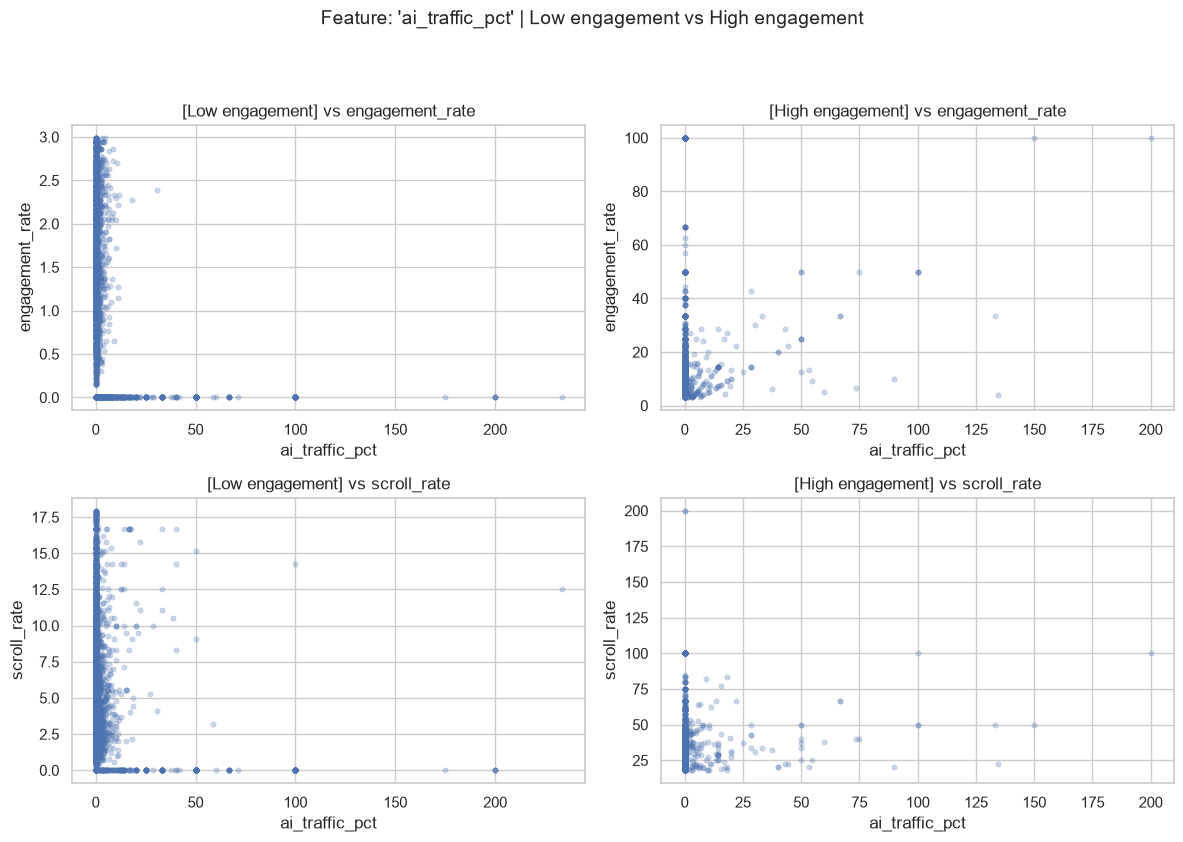

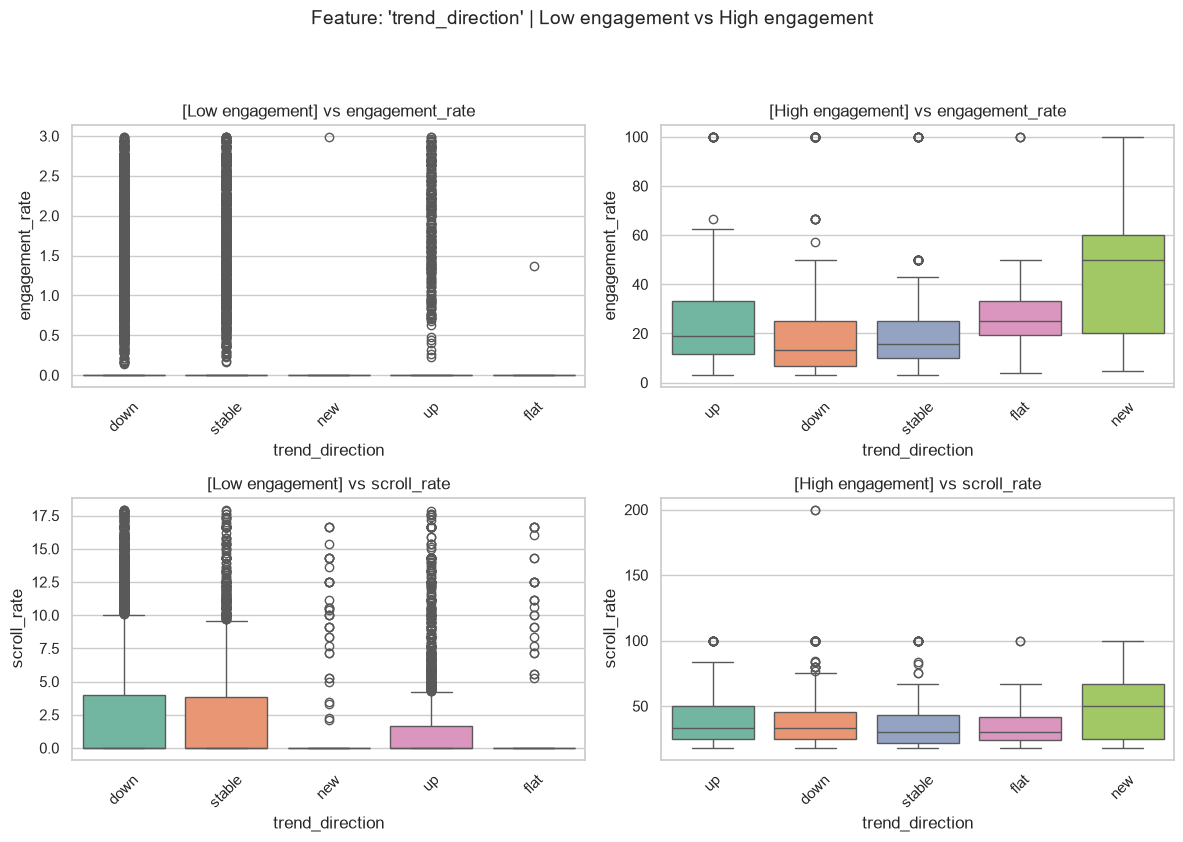

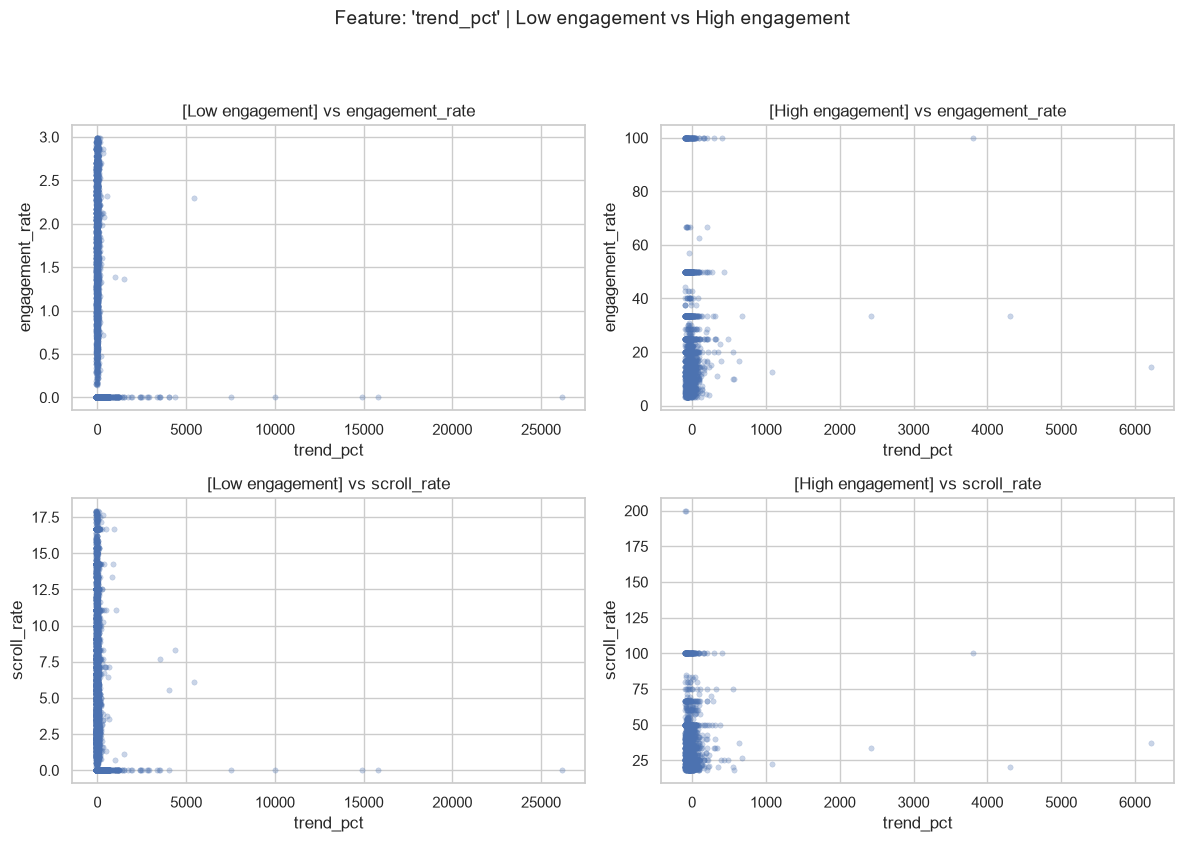

In [17]:
plot_features_vs_targets_side_by_side(
    df1=df_low_eng, 
    df2=df_high_eng, 
    label1="Low engagement", 
    label2="High engagement", 
    feature_cols=feature_cols, 
    target_cols=target_cols
)

In [18]:
# Dictionary to store value counts for every categorical column
categorical_summary = {col: df[col].value_counts() for col in df.select_dtypes(include=['string', 'category'])}

# Example: View the summary for 'content_type'
print(categorical_summary.get('content_type'))
print(categorical_summary.get('trend_direction'))
print(categorical_summary.get('position_tier'))
print(categorical_summary.get('impression_tier'))
print(categorical_summary.get('word_count_tier'))
print(categorical_summary.get('freshness_tier'))
print(categorical_summary.get('content_type'))
print(categorical_summary.get('main_intent'))
print(categorical_summary.get('competition_level'))

content_type
keyword article       27207
feedly article         2096
comparison article      697
Name: count, dtype: int64
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64
position_tier
page_1      11814
striking     7304
page_3_5     7242
top_3        2321
deep         1319
Name: count, dtype: int64
impression_tier
low          11248
moderate     10469
good          7205
excellent     1078
Name: count, dtype: int64
word_count_tier
2000-3500    11263
3500+         6285
1000-2000     3780
<1000          973
Name: count, dtype: int64
freshness_tier
0-30      20480
91-180     9171
31-90       175
181+        174
Name: count, dtype: int64
content_type
keyword article       27207
feedly article         2096
comparison article      697
Name: count, dtype: int64
main_intent
informational    17235
transactional     5733
commercial        4612
navigational        46
Name: count, dtype: int64
competition_level
LOW       228

## 3. Success metric

*One metric you can defend. What number means 'good'?*

**word_count<1000 and char_count<8000**


These are less in number compared to other categories of word_count_tier and char_count_tier respectively, yet give a higher value of ctr than the mean ctr.

## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

In [30]:
from datasets import load_dataset
ds = load_dataset("FlyRank/internship-warehouse", "fact_content_daily_performance", streaming=True, split="train",token="")
df_ds = pd.DataFrame(ds.take(10))
df_ds

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,0
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,0
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,0
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,0
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,0
5,2025-01-27,client_9958f0a7ae1df715,content_c782fa8abd4fce5e,True,True,True,False,21,0,1050,...,0,0,0,0,0,0,0,0,0,0
6,2025-01-27,client_9958f0a7ae1df715,content_ae5e5fd6edff550f,True,True,True,False,13,0,127,...,0,0,0,0,0,0,0,0,0,0
7,2025-01-27,client_9958f0a7ae1df715,content_a64143f6e4a21ffe,True,True,True,False,29,0,356,...,0,0,0,0,0,0,0,0,0,0
8,2025-01-27,client_9958f0a7ae1df715,content_e281674658070602,True,True,True,False,5,0,103,...,0,0,0,0,0,0,0,0,0,0
9,2025-01-27,client_9958f0a7ae1df715,content_658f53fa439c66ca,True,True,True,False,8,0,304,...,0,0,0,0,0,0,0,0,0,0


one row per report date, pseudonymized client, and pseudonymized content item

In [ ]:
from datasets import load_dataset
ds = load_dataset("FlyRank/internship-warehouse", "fact_content_query_90d", streaming=True, split="train",token="")
df_ds = pd.DataFrame(ds.take(10))
df_ds

,client_hash_id,content_hash_id,query_hash_id,query_char_count,query_token_count,window_start,window_end,impressions_90d,clicks_90d,impressions_last30,...,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,avg_position_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_58b1b001f839d699,17,3,2026-04-02,2026-06-30,11,0,0,...,11,0,10.818182,NaN,10.818182,1466,14,32,0.043656,0.725102
1,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_922b8eca2a24cd34,34,7,2026-04-02,2026-06-30,13,0,0,...,1,0,1.769231,NaN,11.000000,1466,14,32,0.043656,0.725102
2,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_9f0c36a6ae2a6a99,16,2,2026-04-02,2026-06-30,16,0,11,...,5,0,23.562500,24.272727,22.000000,1466,14,32,0.043656,0.725102
3,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_a032820b5467e996,24,4,2026-04-02,2026-06-30,55,0,1,...,1,0,2.200000,13.000000,0.000000,1466,14,32,0.043656,0.725102
4,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_ba1a2f131961c5da,18,3,2026-04-02,2026-06-30,14,0,0,...,0,0,3.428571,NaN,NaN,1466,14,32,0.043656,0.725102
5,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_bf21a07e311fed62,18,3,2026-04-02,2026-06-30,40,0,3,...,3,0,2.775000,5.000000,12.000000,1466,14,32,0.043656,0.725102
6,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_c9de7d945a73e134,29,4,2026-04-02,2026-06-30,16,0,5,...,6,0,17.062500,18.600000,17.333333,1466,14,32,0.043656,0.725102
7,client_08a6a72ff48e62c0,content_447b93d5ff670356,query_9dfad337ed50a6f9,26,5,2026-04-02,2026-06-30,14,0,1,...,2,0,52.571429,49.000000,56.000000,339,2,32,0.162242,0.696165
8,client_08a6a72ff48e62c0,content_447b93d5ff670356,query_ba4af1d8841d0c41,35,6,2026-04-02,2026-06-30,34,0,1,...,18,0,88.058824,91.000000,87.111111,339,2,32,0.162242,0.696165
9,client_08a6a72ff48e62c0,content_4483e354a2992497,query_0f5dc12980d1d9b9,23,3,2026-04-02,2026-06-30,11,0,1,...,1,0,13.636364,57.000000,11.000000,2169,13,41,0.051176,0.799447


one row per pseudonymized client, content item, and query hash over the fixed 90-day window

## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

* Patterns where days_with_impressions and freshness_tier maybe a lil biased to larger ctr for 181+ category. There may be other features that need to be considered too. ML will learn those on it's own.
* Many features follow a parabola structure.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.